# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 11     |  |
| :-------------|:-------------|
| Hugo Rutten | 6541593 |
| Yael Jawahierkhan | 6444504 |
| Matteo Leonardi | 6391494 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Yael Jawahierkhan','Matteo Leonardi']

## Opdracht 1: Planning.

| Planning Groep: 11     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibreren van de sensor af | 11:30 |
| Testen meetopstelling | 12:00 |
| Algoritme iteratie 0 af | 15:00 |
| Iteraties maken | 16:30 |
| Alles testen en opruimen | 16:30-17:30 |
| groep aanwezig 1| 10:45 |
| Pauze 1| 12:45-13:45 |


## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [11]

<img src="KalibratieOpstelling.jpeg" width="400">

a= 0.03440668755754128
b =  0.3237959096074584


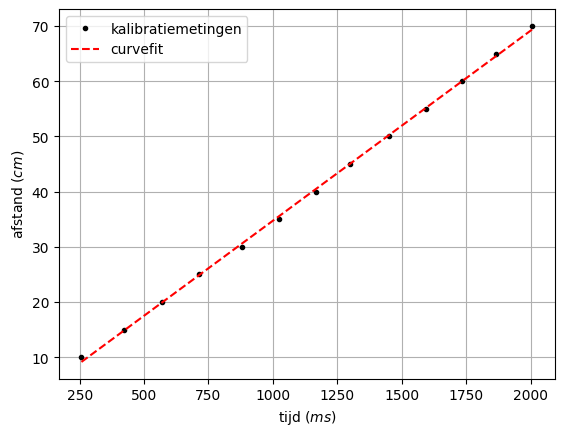

In [3]:
# verwerk hier jullie kalibratiemetingen
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


tijden = np.array([257,424,569,715,881,1023,1167,1301,1450,1595,1735,1867,2007]) #ms
afstanden = np.array([10.0,15.0,20.0, 25.0,30.0,35.0,40.0,45.0,50.0,55.0,60.0,65.0,70.0]) #cm

x_test = np.linspace(np.min(tijden),np.max(tijden))

def fit(x,a,b):
    return a*x+b

val, cov = curve_fit(fit,tijden,afstanden)

print('a=', val[0])
print( 'b = ', val[1])


plt.figure()
plt.plot(tijden,afstanden,'k.',label='kalibratiemetingen')
plt.plot(x_test,fit(x_test,*val),'r--',label='curvefit')
plt.ylabel('afstand $(cm)$')
plt.xlabel('tijd $(ms)$')
plt.grid()
plt.legend()
plt.show()


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  44.47
1   0  30   0  20  45.52
2  40   0  30   0  47.95
3  30   0  20   0  47.58


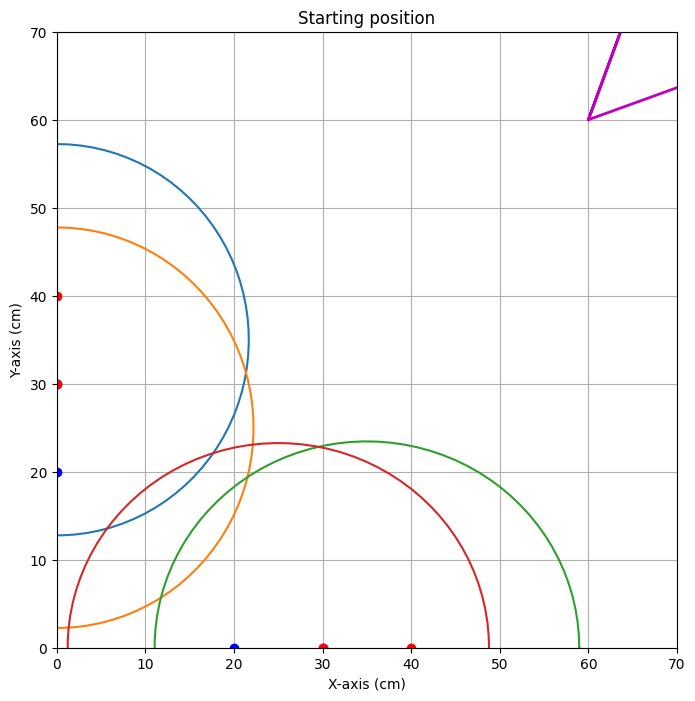


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=95.575


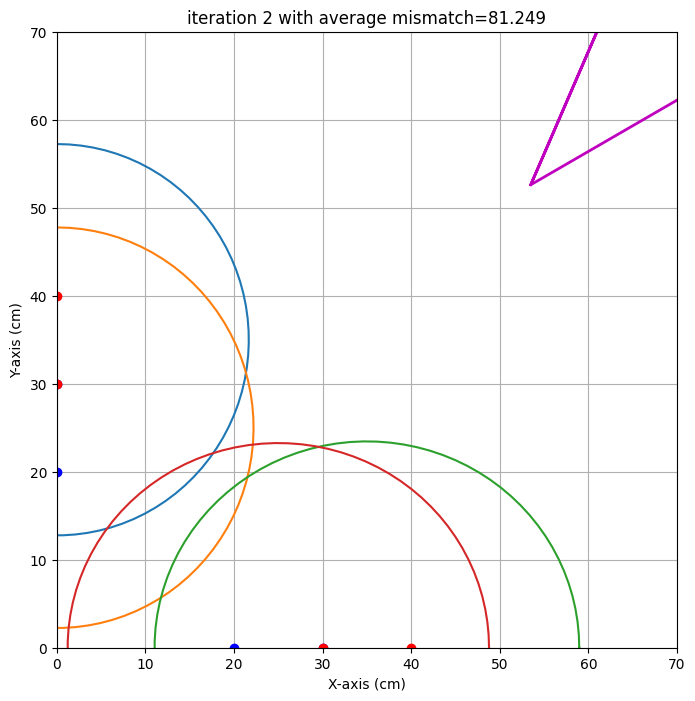

end iteration 2 with average mismatch=81.249


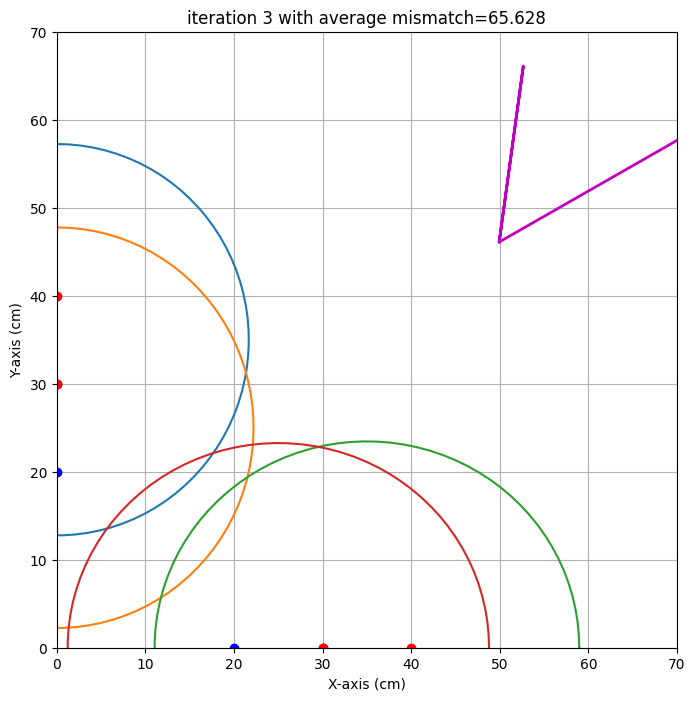

end iteration 3 with average mismatch=65.628


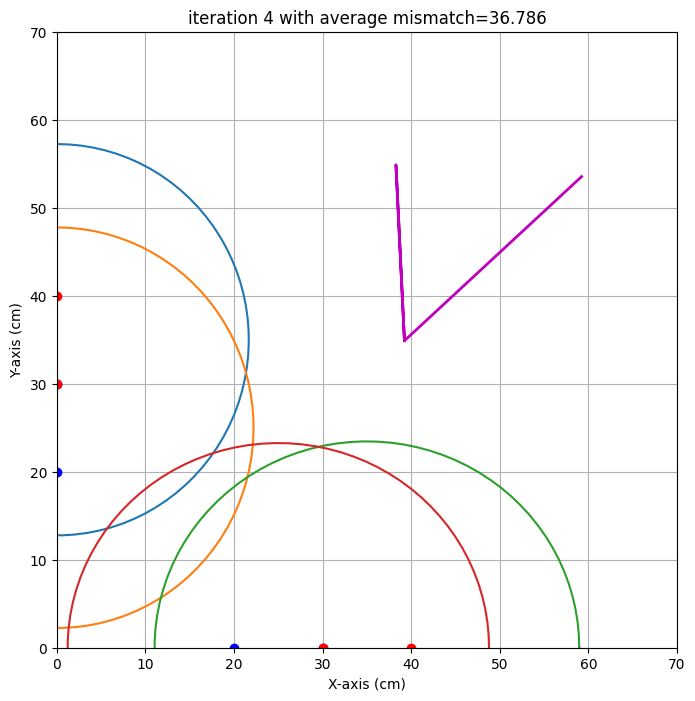

end iteration 4 with average mismatch=36.786


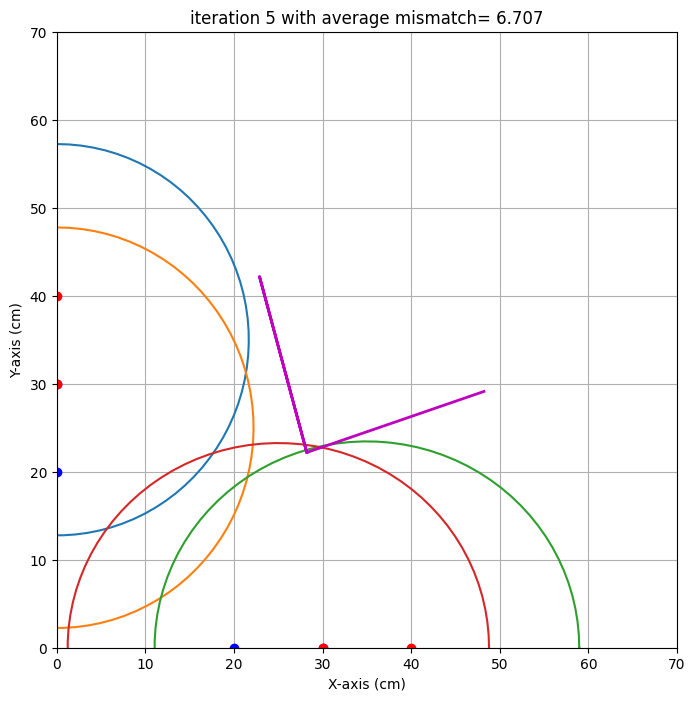

end iteration 5 with average mismatch= 6.707


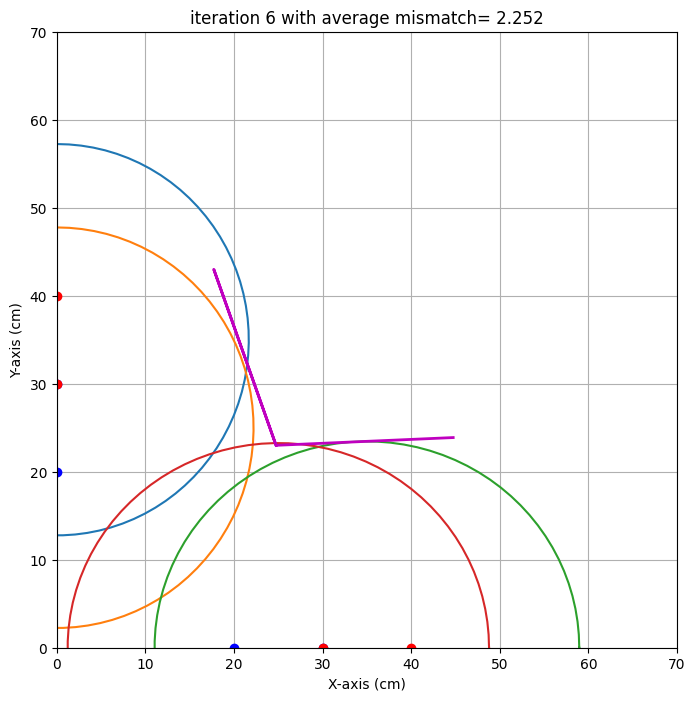

end iteration 6 with average mismatch= 2.252


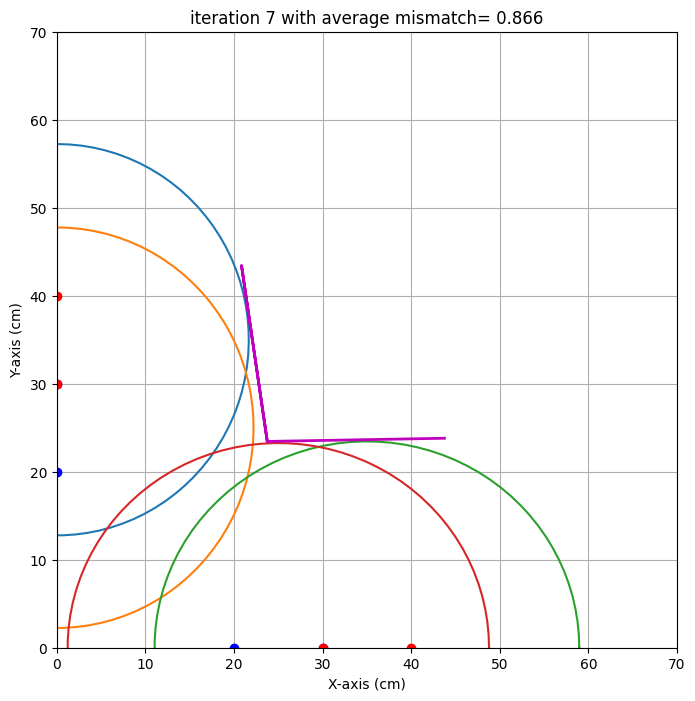

end iteration 7 with average mismatch= 0.866


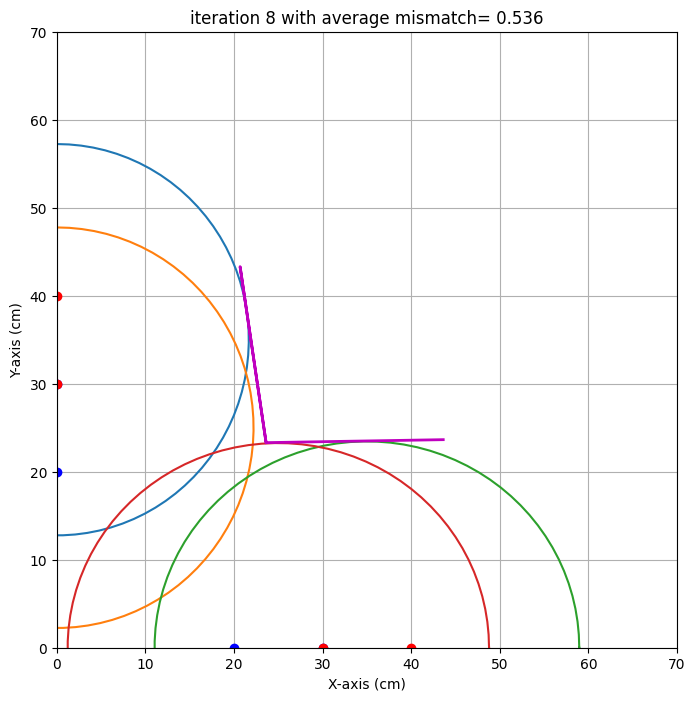

end iteration 8 with average mismatch= 0.536
end iteration 9 with average mismatch= 0.534
end iteration 10 with average mismatch= 0.534
end iteration 11 with average mismatch= 0.534
end iteration 12 with average mismatch= 0.534
end iteration 13 with average mismatch= 0.534
end iteration 14 with average mismatch= 0.534
end iteration 15 with average mismatch= 0.534
end iteration 16 with average mismatch= 0.534
end iteration 17 with average mismatch= 0.534
end iteration 18 with average mismatch= 0.534
end iteration 19 with average mismatch= 0.534
end iteration 20 with average mismatch= 0.534
end iteration 21 with average mismatch= 0.534


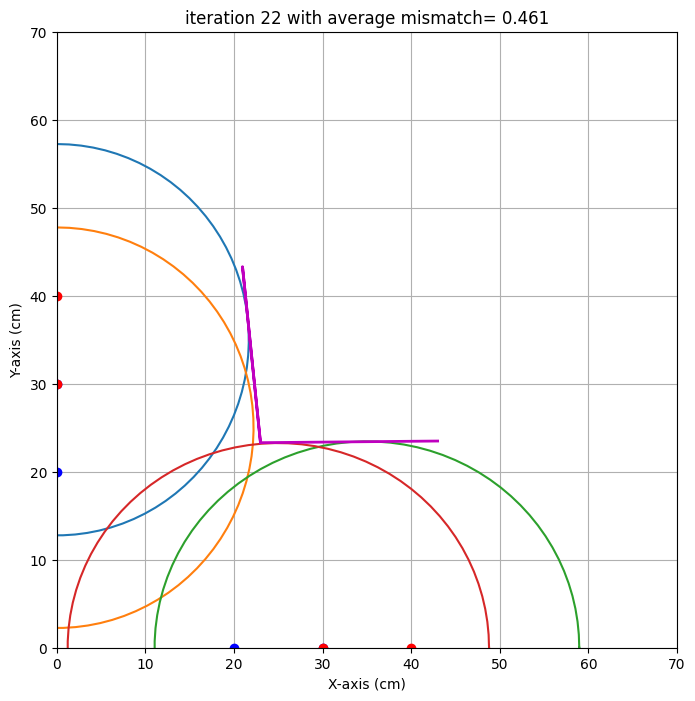

end iteration 22 with average mismatch= 0.461
end iteration 23 with average mismatch= 0.437
end iteration 24 with average mismatch= 0.395
end iteration 25 with average mismatch= 0.380
end iteration 26 with average mismatch= 0.375
end iteration 27 with average mismatch= 0.375
end iteration 28 with average mismatch= 0.374
end iteration 29 with average mismatch= 0.374
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.374
###############################################################################
end of iteration  30
Best alpha=  -0.97 with uncertainty=   3.31
Best beta =  -4.32 with uncertainty=   0.43
Best x0   =  22.57 with uncertainty=   0.17
Best y0   =  23.71 with uncertainty=   0.28
###############################################################################


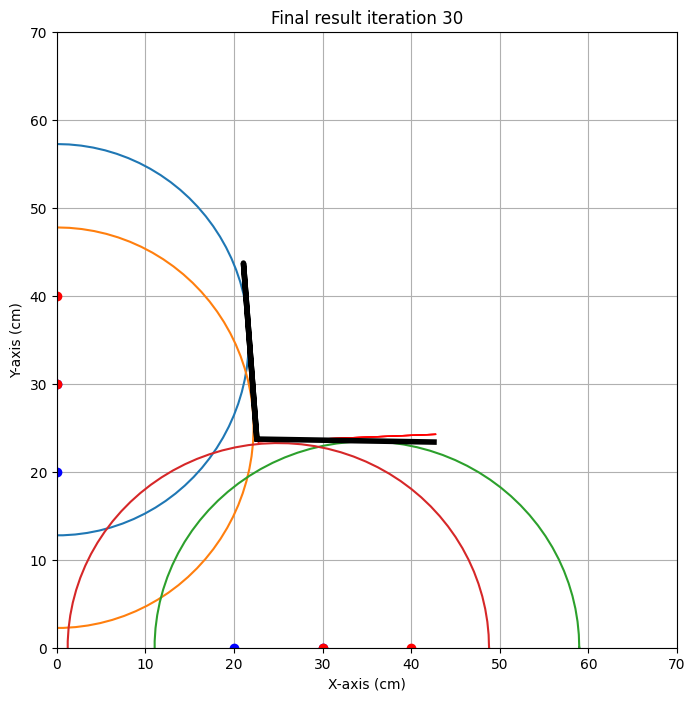

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,44.47],
    [0,30,0,20,45.52],
    #[0,10,0,20,193.37],
    [40,0,30,0,47.95],
    [30,0,20,0,47.58],
    #[10,0,20,0,190.56],
    #[10,0,0,10,191.41]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 22.6 cm met een standaardafwijking van 0.2 cm 
y0: 23.7 cm met een standaardafwijking van 0.3 cm 
alpha: -1.0 graden met een standaardafwijking van 3.3 graad 
beta: -4.3 graden met een standaardafwijking van 0.4 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Hugo Rutten]

Voeg een foto in van het algoritme van het eerste groepslid

<img src="SchemaHugo.jpeg" width="400">

#### algoritme [Yael Jawahierkhan]

Voeg een foto in van het algoritme van het tweede groepslid

<img src="SchemaYael.jpeg" width="400">

#### algoritme [Matteo Leonardi]

Voeg een foto in van het algoritme van het derde groepslid

<img src="SchemaMatteo.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 24,   
           'y0': 31,
           'alpha': 25,  
           'beta': 10,  
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Yael Jawahierkhan' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
  [62.4,0,52.5,0,83.5],
    [0,62.5,0,52.5,65.2],
    #[0,70,0,60,200],
    #[70,0,60,0,200],

    ]),
       'Matteo Leonardi' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
  [70,0,50,0,87.8],
    [60,0,40,0,79.6],
    [60,0,50,0,81.5],
    [0,70,0,50,67.9],  
    [0,60,0,40,63.6],
    [0,60,0,50,63.2],
    ])}

## Opdracht 7: Evaluatie.

Yael Jawahierkhan
Running the imaging algorithm with the following data:
     xs    ys    xr    yr     R
0  62.4   0.0  52.5   0.0  83.5
1   0.0  62.5   0.0  52.5  65.2


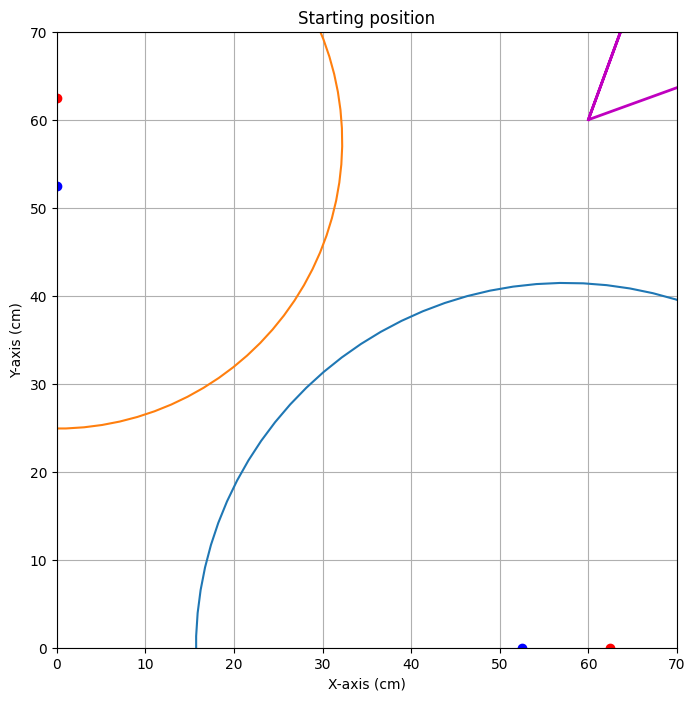


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=51.706


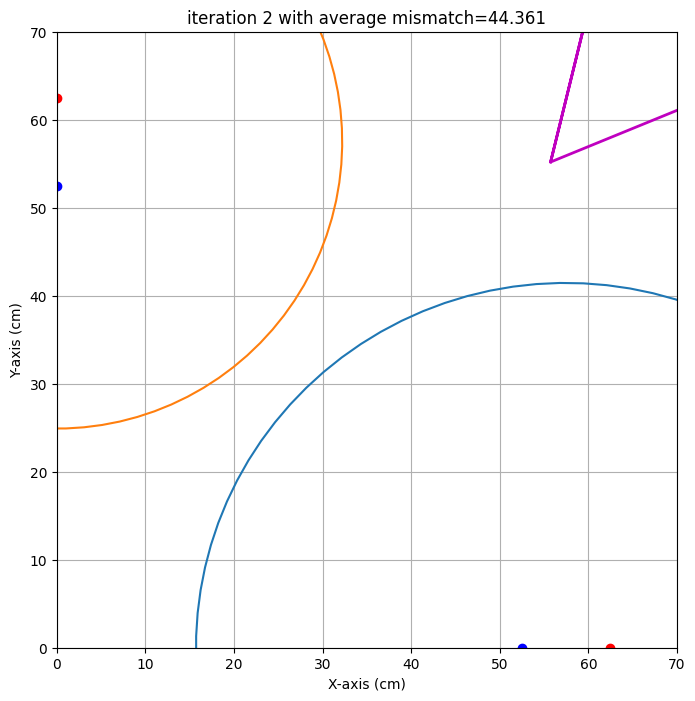

end iteration 2 with average mismatch=44.361


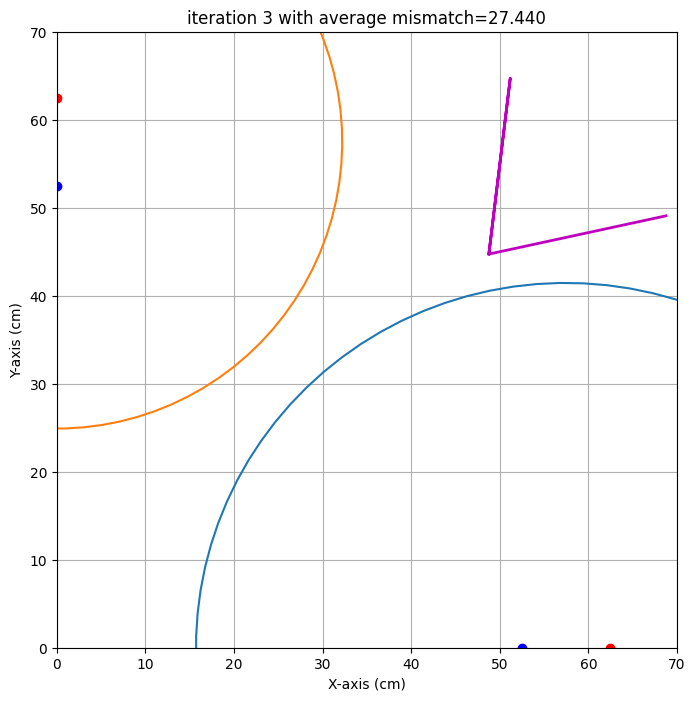

end iteration 3 with average mismatch=27.440


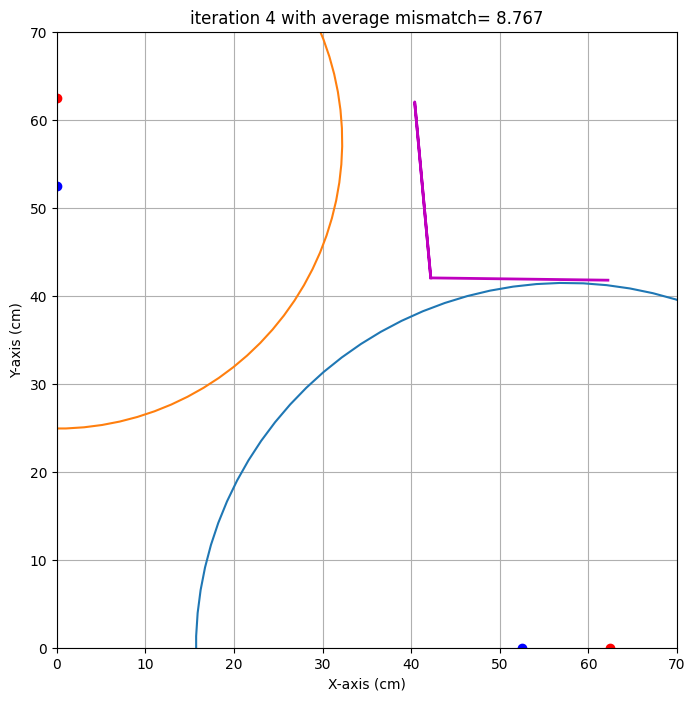

end iteration 4 with average mismatch= 8.767


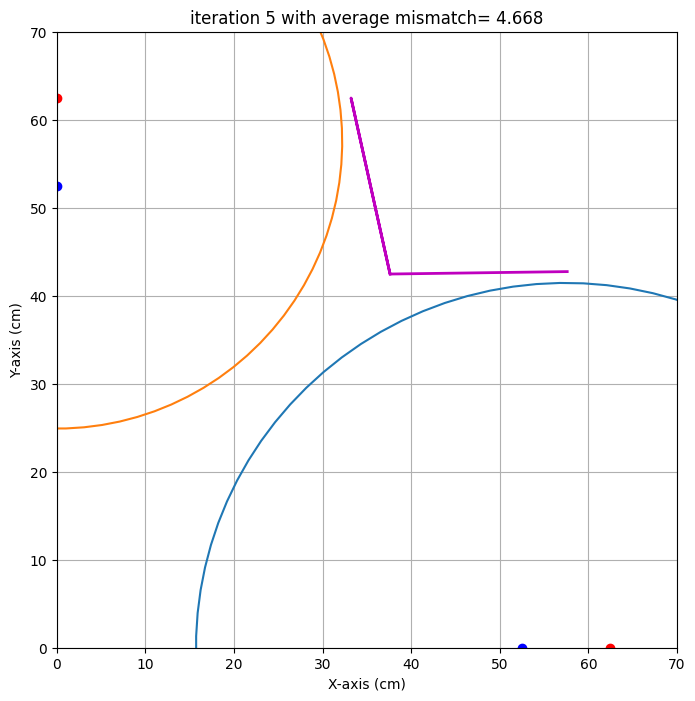

end iteration 5 with average mismatch= 4.668


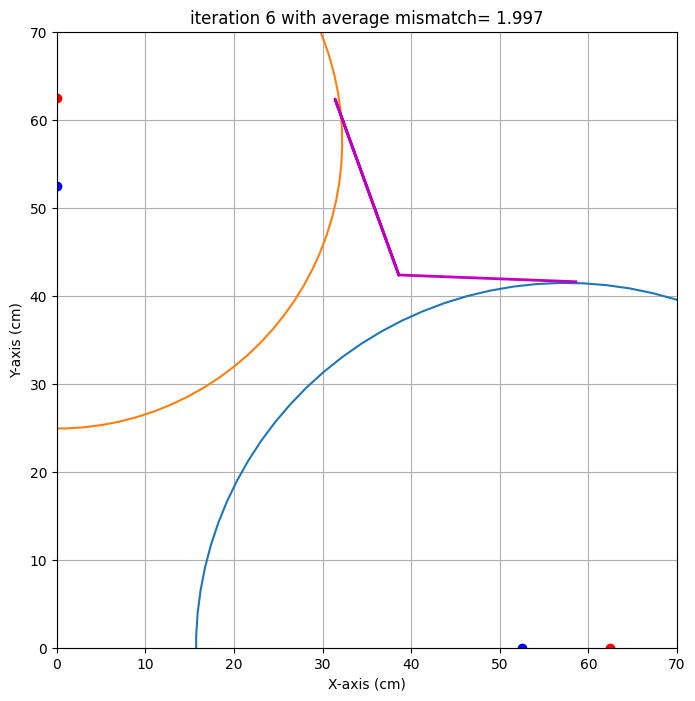

end iteration 6 with average mismatch= 1.997


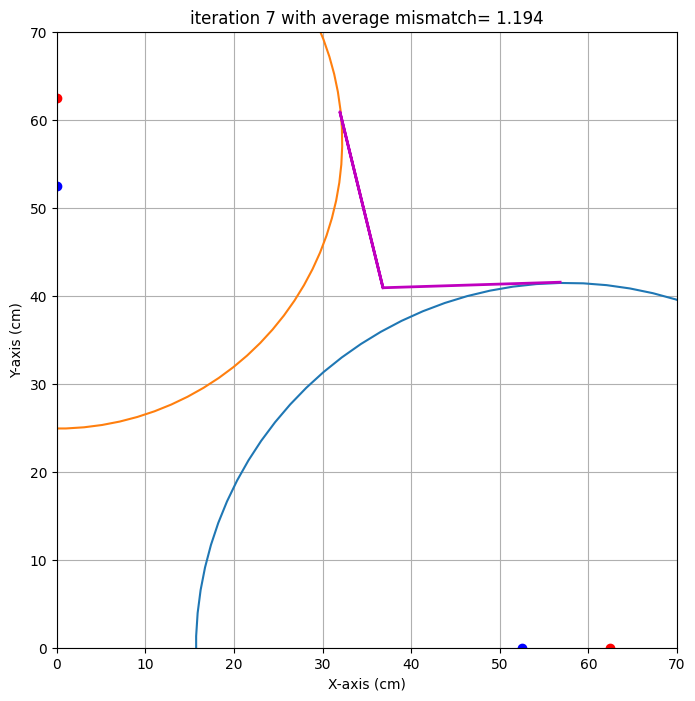

end iteration 7 with average mismatch= 1.194
end iteration 8 with average mismatch= 1.149
end iteration 9 with average mismatch= 1.128


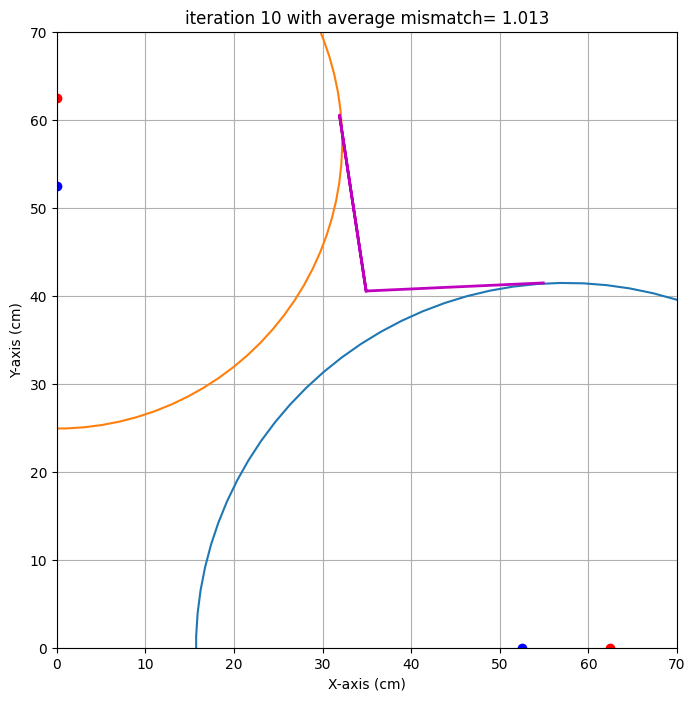

end iteration 10 with average mismatch= 1.013


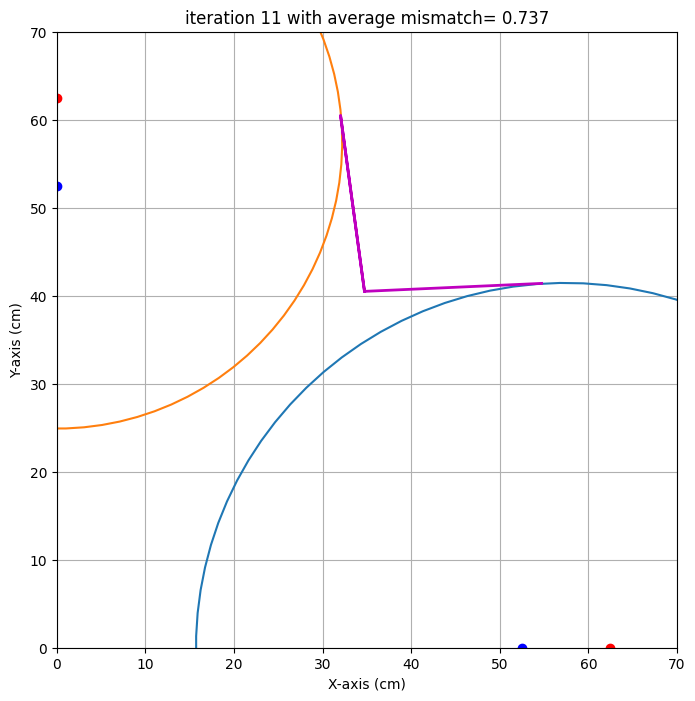

end iteration 11 with average mismatch= 0.737
end iteration 12 with average mismatch= 0.735
end iteration 13 with average mismatch= 0.735
end iteration 14 with average mismatch= 0.735
end iteration 15 with average mismatch= 0.735
end iteration 16 with average mismatch= 0.735
end iteration 17 with average mismatch= 0.735
end iteration 18 with average mismatch= 0.735
end iteration 19 with average mismatch= 0.735
end iteration 20 with average mismatch= 0.735
end iteration 21 with average mismatch= 0.735


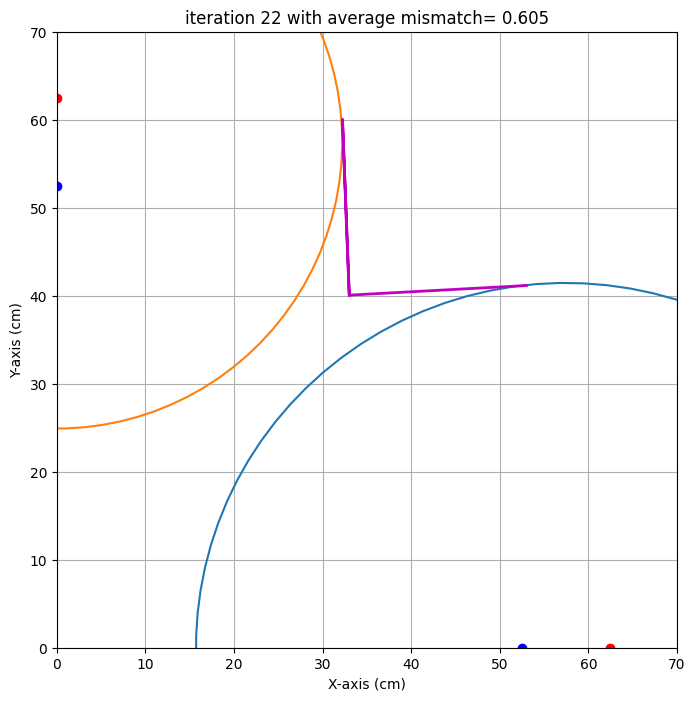

end iteration 22 with average mismatch= 0.605


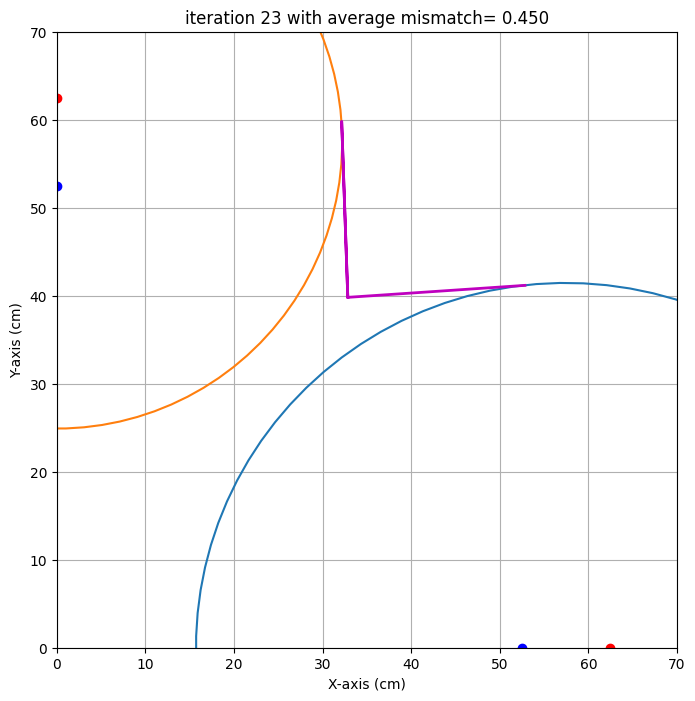

end iteration 23 with average mismatch= 0.450


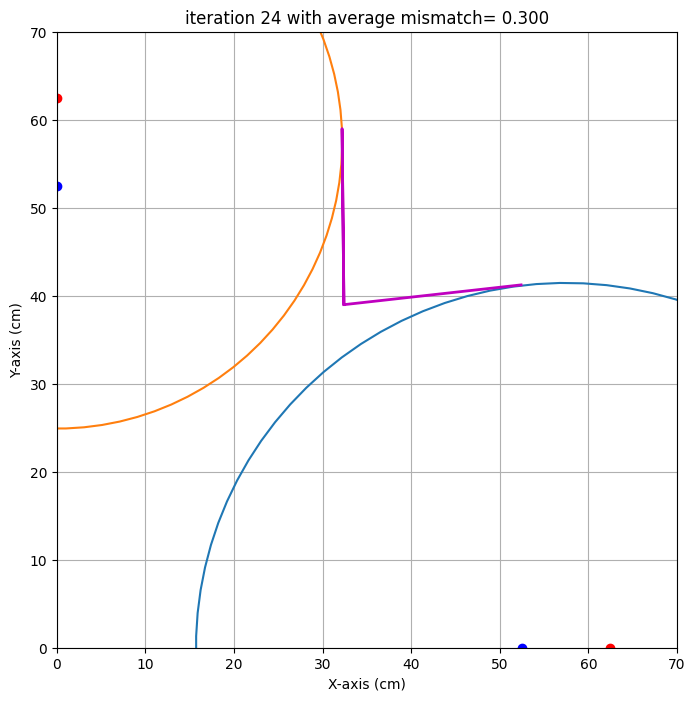

end iteration 24 with average mismatch= 0.300


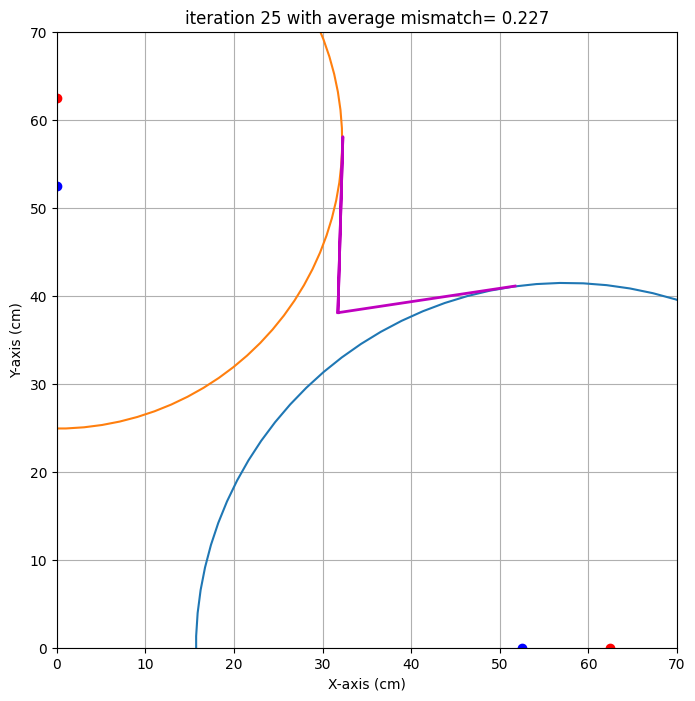

end iteration 25 with average mismatch= 0.227


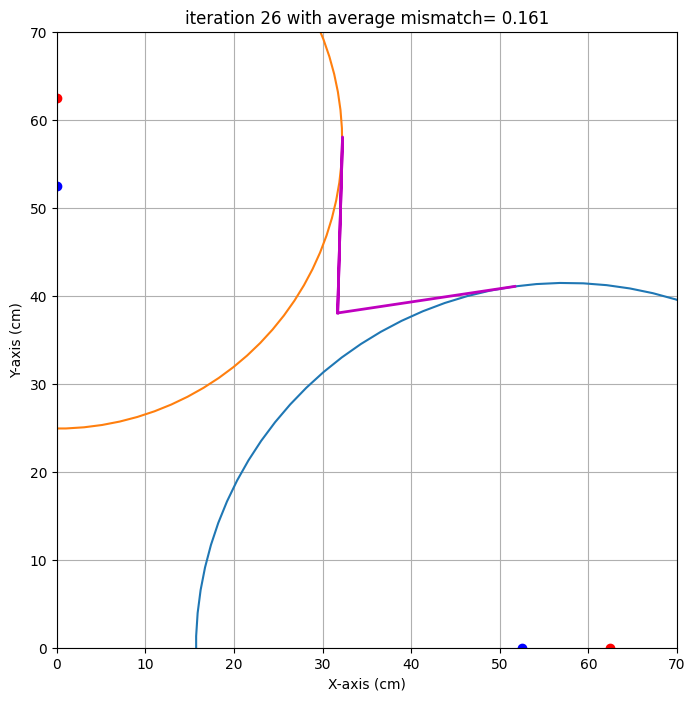

end iteration 26 with average mismatch= 0.161
end iteration 27 with average mismatch= 0.158
end iteration 28 with average mismatch= 0.157
end iteration 29 with average mismatch= 0.156
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.156
###############################################################################
end of iteration  30
Best alpha=   8.58 with uncertainty=  11.45
Best beta =   1.57 with uncertainty=  11.30
Best x0   =  31.69 with uncertainty=   4.16
Best y0   =  38.04 with uncertainty=   4.59
###############################################################################


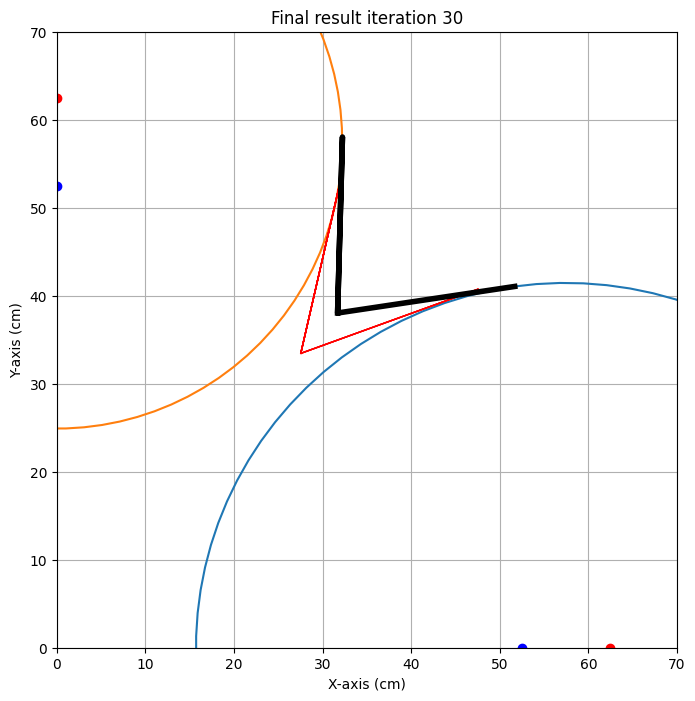

{'alpha': np.float64(8.578584453903376), 'alpha_eps': np.float64(11.44804553570478), 'beta': np.float64(1.569633729695534), 'beta_eps': np.float64(11.303251606180885), 'x0': np.float64(31.69040962899471), 'x0_eps': np.float64(4.157211629223191), 'y0': np.float64(38.03639685783864), 'y0_eps': np.float64(4.588761049671405)}
Matteo Leonardi
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  70   0  50   0  87.8
1  60   0  40   0  79.6
2  60   0  50   0  81.5
3   0  70   0  50  67.9
4   0  60   0  40  63.6
5   0  60   0  50  63.2


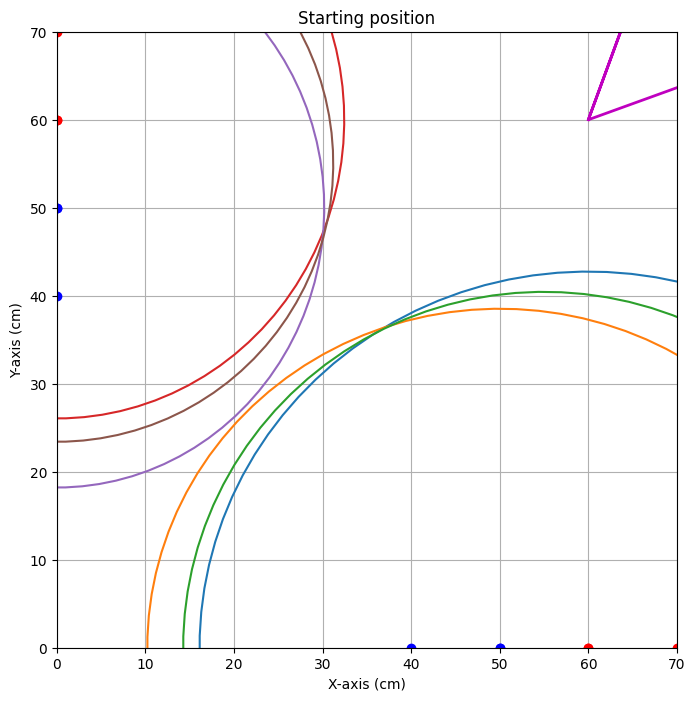


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=53.671


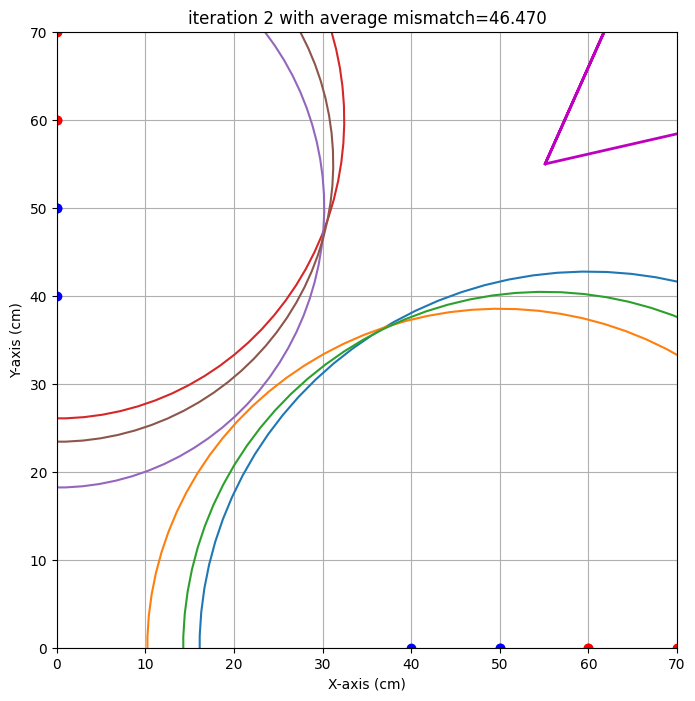

end iteration 2 with average mismatch=46.470


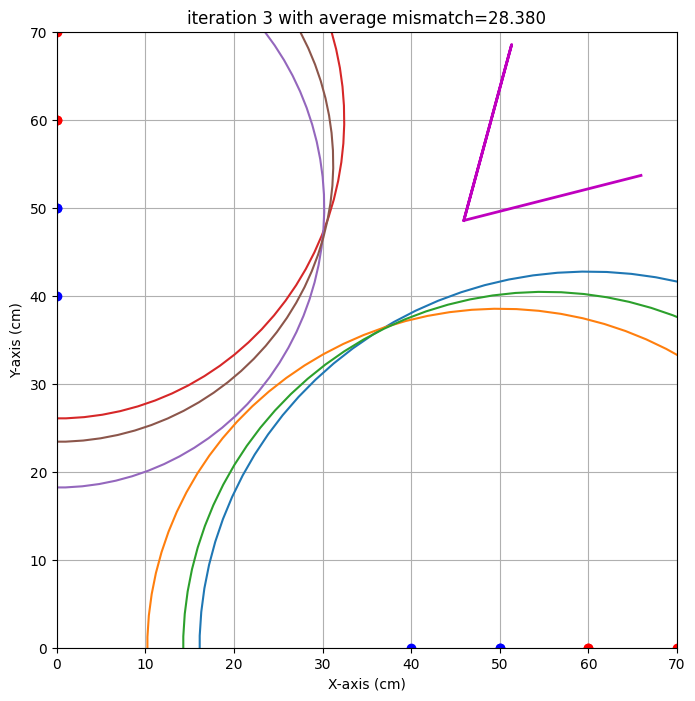

end iteration 3 with average mismatch=28.380


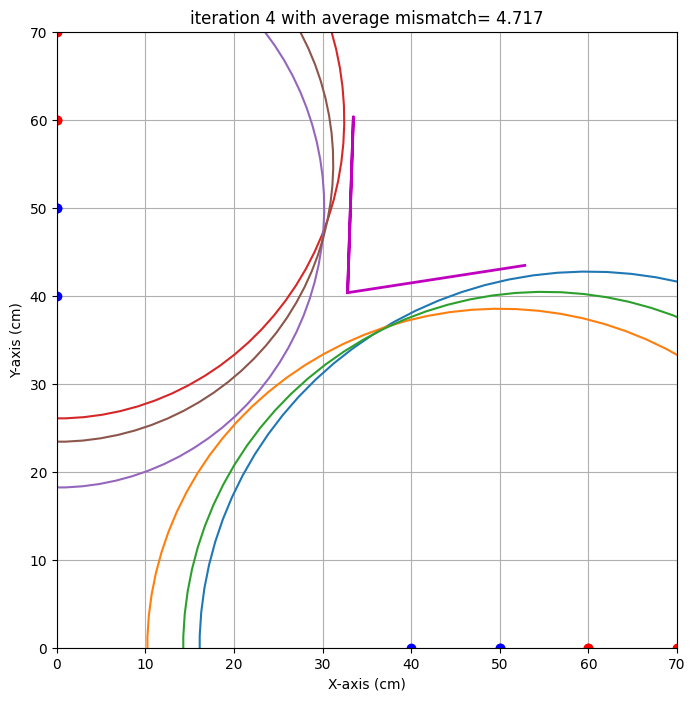

end iteration 4 with average mismatch= 4.717


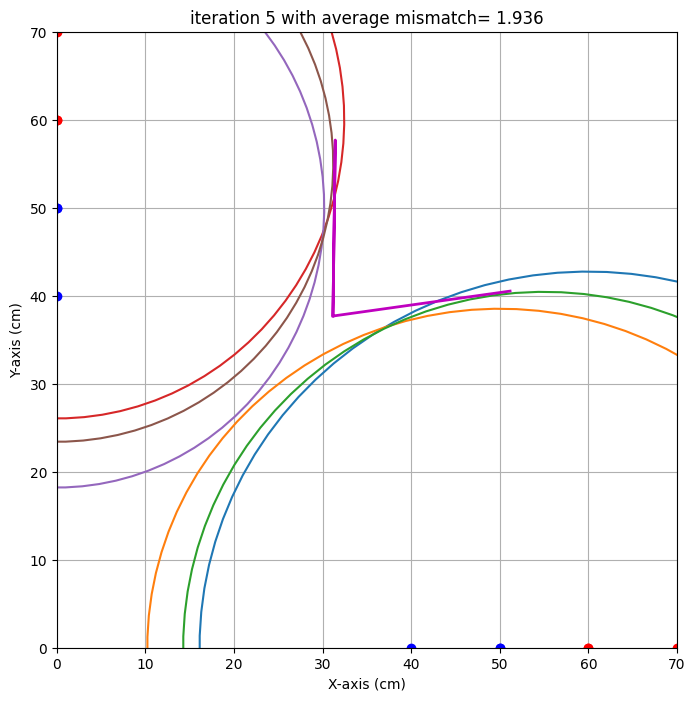

end iteration 5 with average mismatch= 1.936


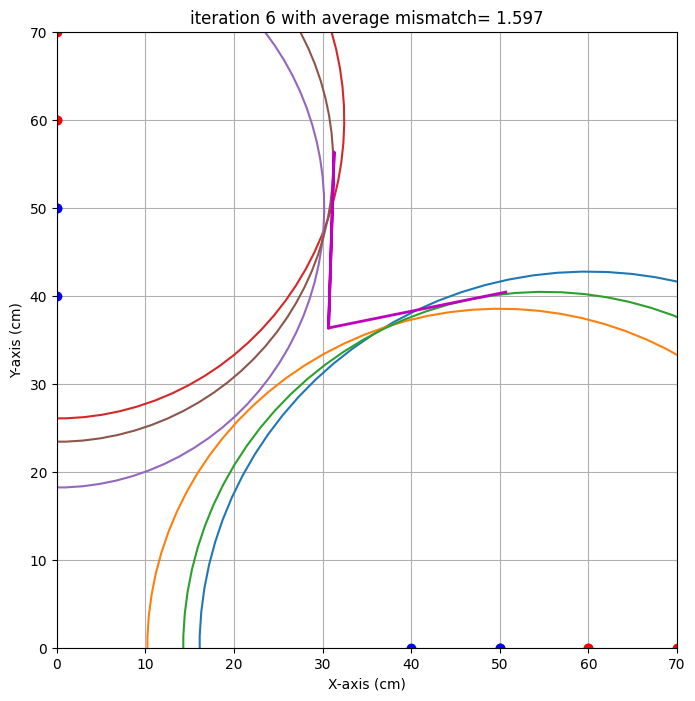

end iteration 6 with average mismatch= 1.597


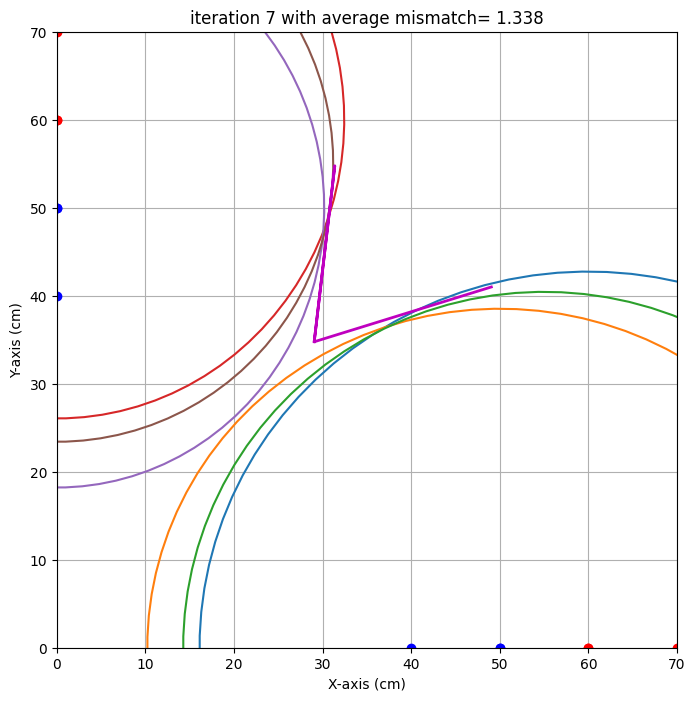

end iteration 7 with average mismatch= 1.338


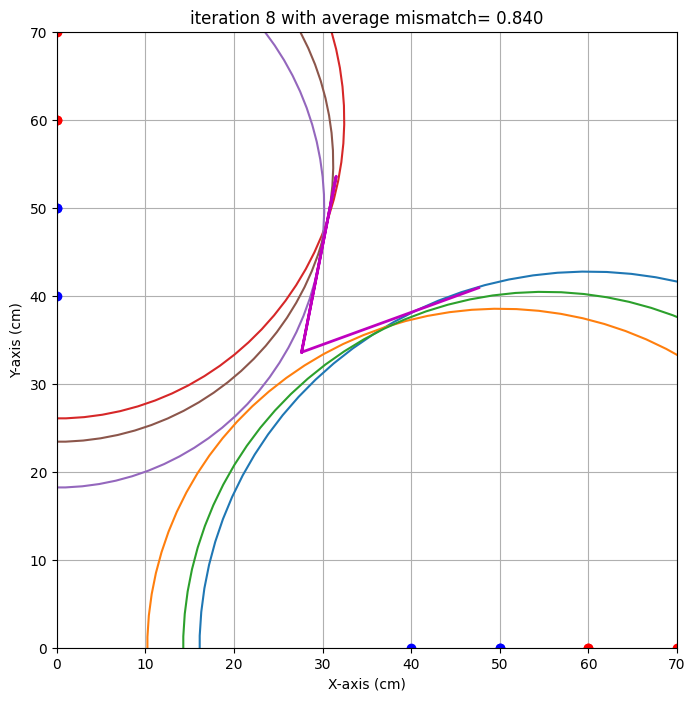

end iteration 8 with average mismatch= 0.840


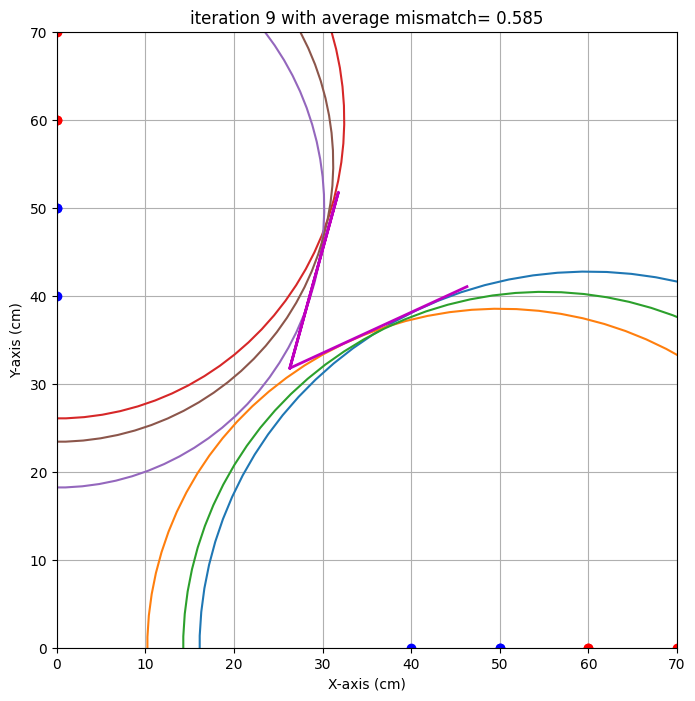

end iteration 9 with average mismatch= 0.585


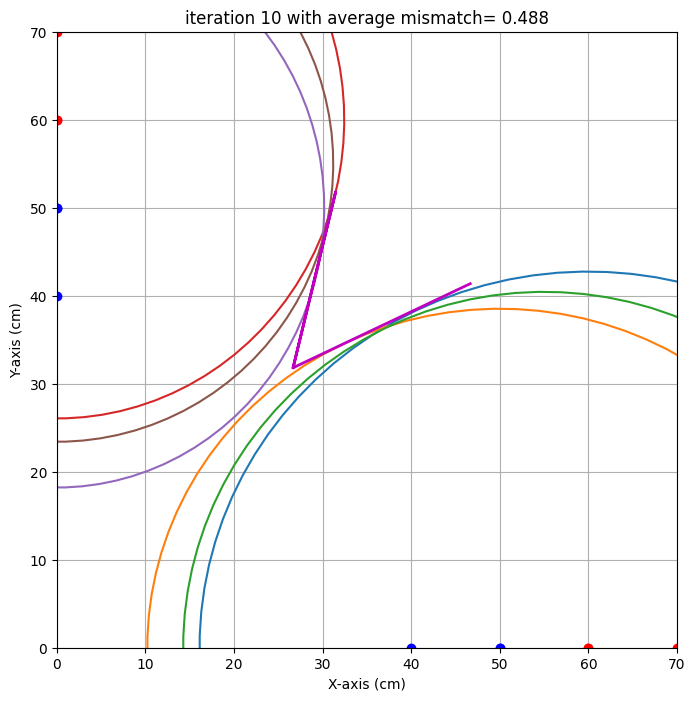

end iteration 10 with average mismatch= 0.488
end iteration 11 with average mismatch= 0.488
end iteration 12 with average mismatch= 0.488
end iteration 13 with average mismatch= 0.488
end iteration 14 with average mismatch= 0.488
end iteration 15 with average mismatch= 0.488
end iteration 16 with average mismatch= 0.488
end iteration 17 with average mismatch= 0.488
end iteration 18 with average mismatch= 0.488
end iteration 19 with average mismatch= 0.488
end iteration 20 with average mismatch= 0.488
end iteration 21 with average mismatch= 0.488
end iteration 22 with average mismatch= 0.488


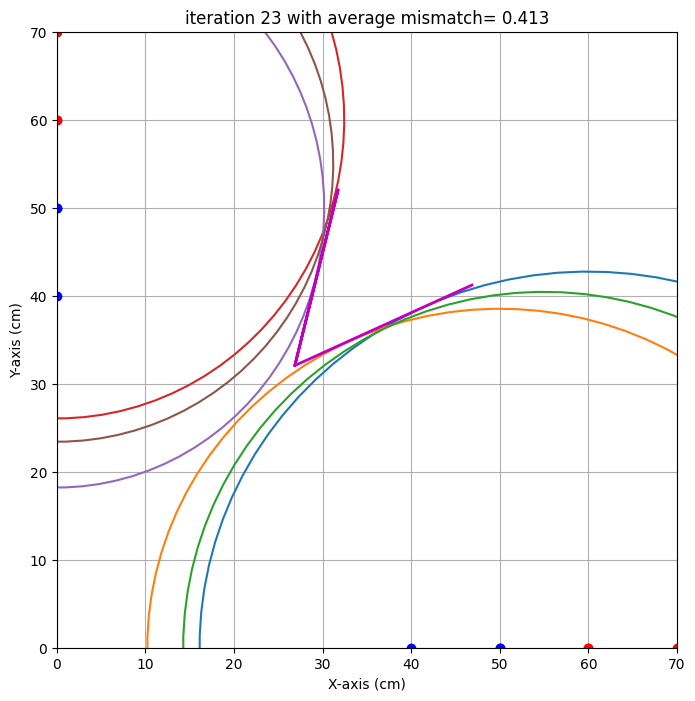

end iteration 23 with average mismatch= 0.413
end iteration 24 with average mismatch= 0.394
end iteration 25 with average mismatch= 0.386
end iteration 26 with average mismatch= 0.384
end iteration 27 with average mismatch= 0.384
end iteration 28 with average mismatch= 0.384
end iteration 29 with average mismatch= 0.384
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.384
###############################################################################
end of iteration  30
Best alpha=  24.56 with uncertainty=   4.23
Best beta =  13.74 with uncertainty=   3.96
Best x0   =  26.83 with uncertainty=   1.43
Best y0   =  32.05 with uncertainty=   1.43
###############################################################################


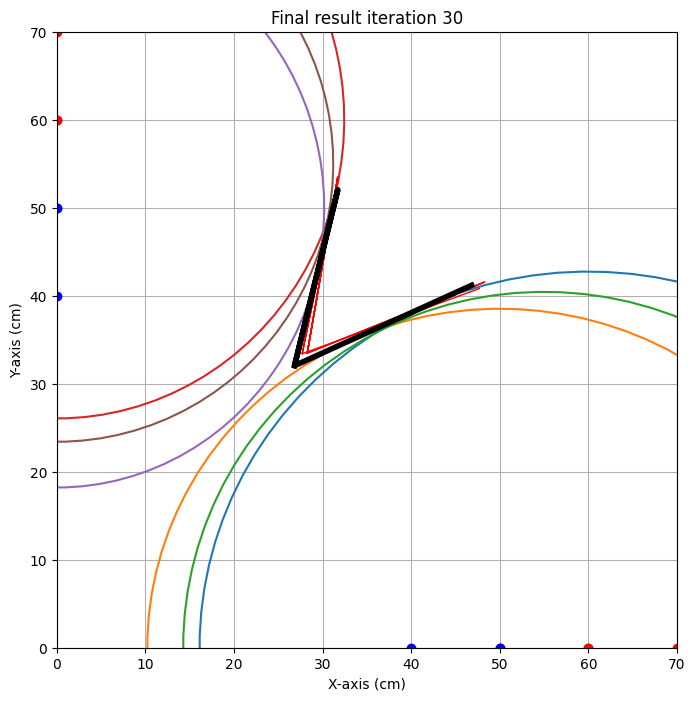

{'alpha': np.float64(24.56046267116278), 'alpha_eps': np.float64(4.234936616336395), 'beta': np.float64(13.736515884999292), 'beta_eps': np.float64(3.9583925515639375), 'x0': np.float64(26.827773220776535), 'x0_eps': np.float64(1.4345630752406073), 'y0': np.float64(32.05068988472677), 'y0_eps': np.float64(1.4292771388381524)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Yael Jawahierkhan 
x0 target is : 24.0. Gevonden waarde: 31.7 cm met een standaardafwijking van 4.2 cm 
y0 target is : 31.0. Gevonden waarde: 38.0 cm met een standaardafwijking van 4.6 cm 
alpha target is : 25.0. Gevonden waarde: 8.6 graden met een standaardafwijking van 11.4 graad 
beta target is : 10.0. Gevonden waarde: 1.6 graden met een standaardafwijking van 11.3 graad 

Matteo Leonardi 
x0 target is : 24.0. Gevonden waarde: 26.8 cm met een standaardafwijking van 1.4 cm 
y0 target is : 31.0. Gevonden waarde: 32.1 cm met een standaardafwijking van 1.4 cm 
alpha target is : 25.0. Gevonden waarde: 24.6 graden met een standaardafwijking van 4.2 graad 
beta target is : 10.0. Gevonden waarde: 13.7 graden met een standaardafwijking van 4.0 graad 



## Opdracht 8: Iteratie1+. 14:49.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: 

![Alt](Iteratie1.jpeg)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  70   0  50   0  87.8
1  60   0  40   0  79.6
2  60   0  50   0  81.5
3   0  70   0  50  67.9
4   0  60   0  40  63.6
5   0  60   0  50  63.2
6  70   0  40   0  84.4
7   0  70   0  40  68.7


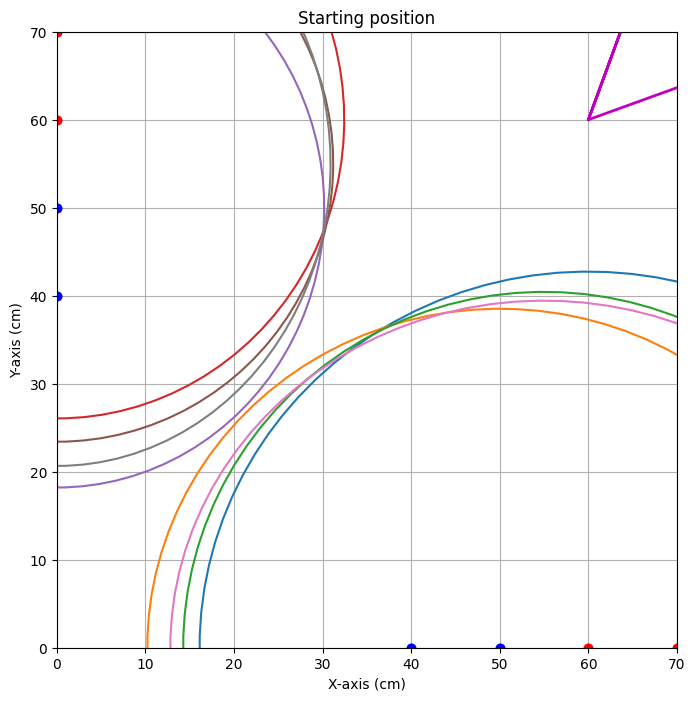


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=53.529


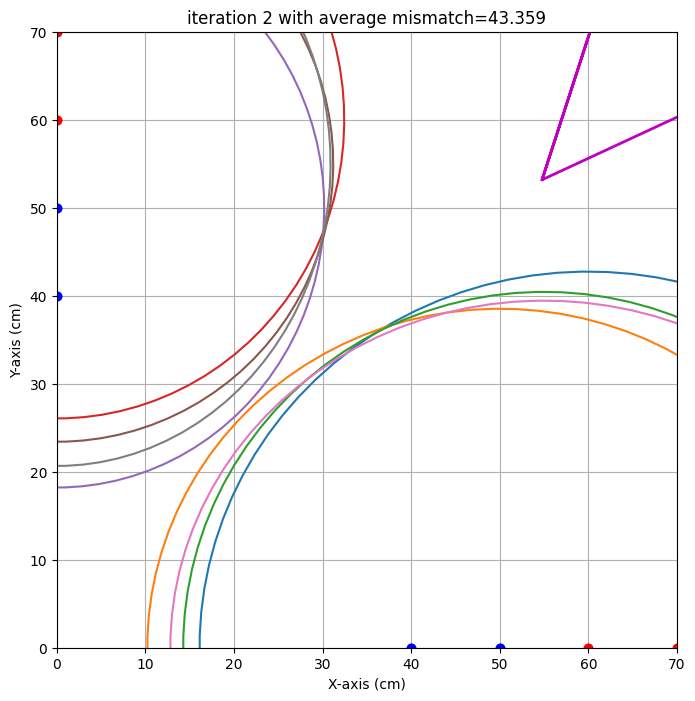

end iteration 2 with average mismatch=43.359


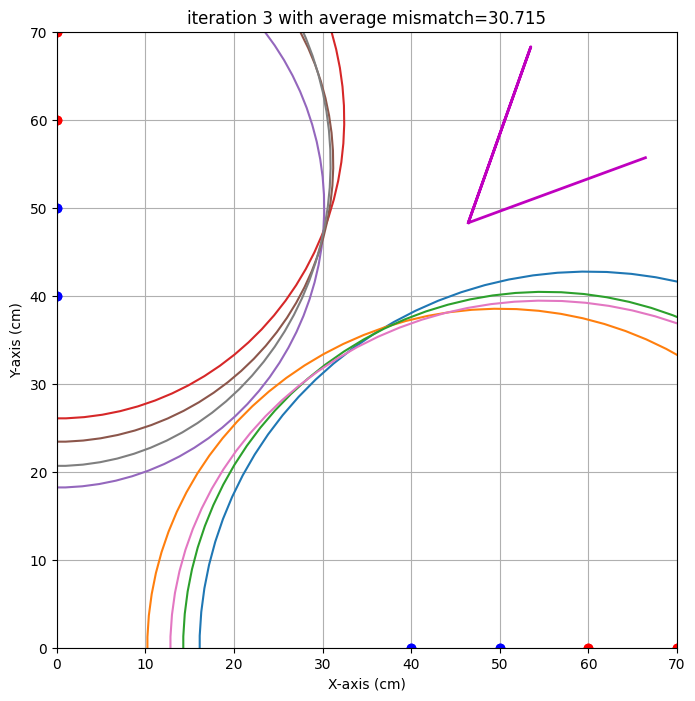

end iteration 3 with average mismatch=30.715


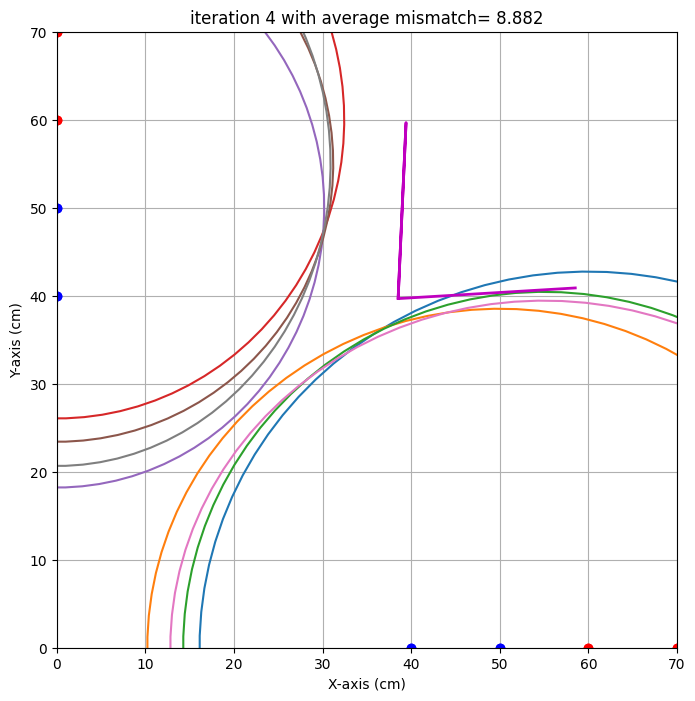

end iteration 4 with average mismatch= 8.882


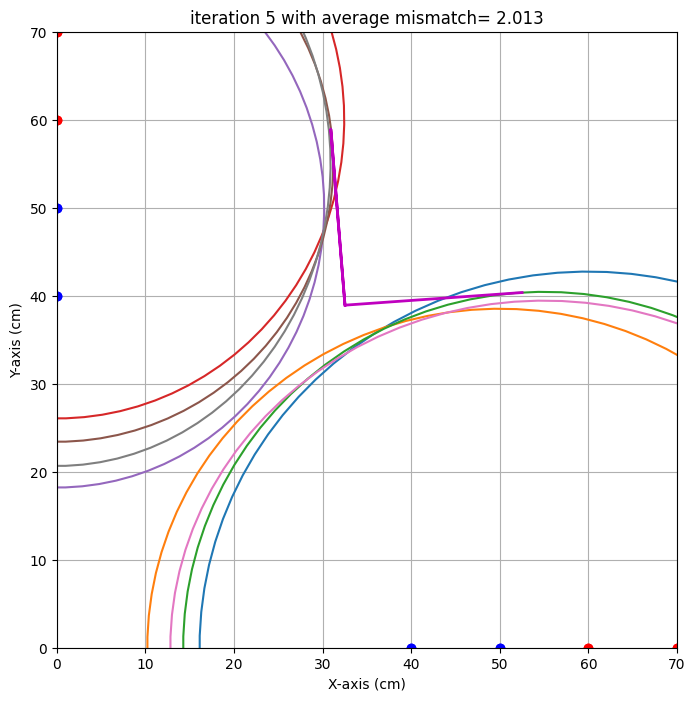

end iteration 5 with average mismatch= 2.013
end iteration 6 with average mismatch= 2.010


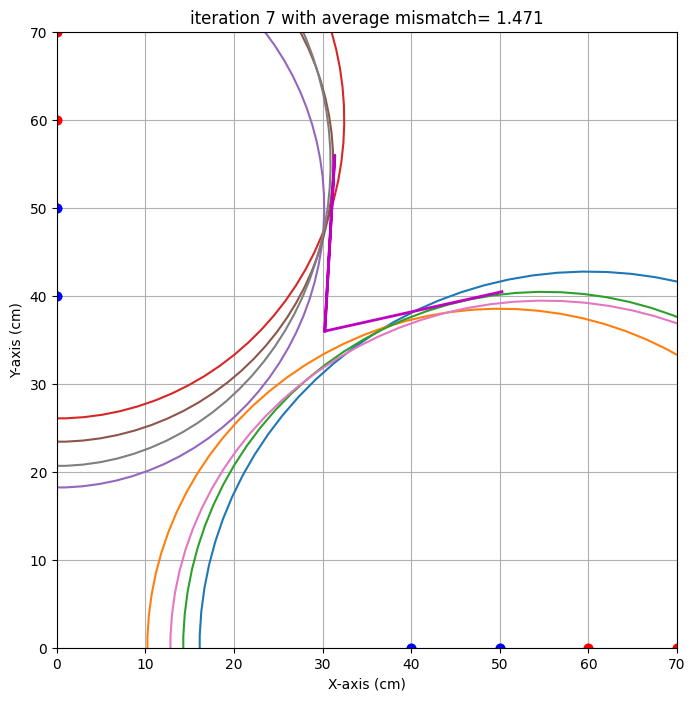

end iteration 7 with average mismatch= 1.471
end iteration 8 with average mismatch= 1.430


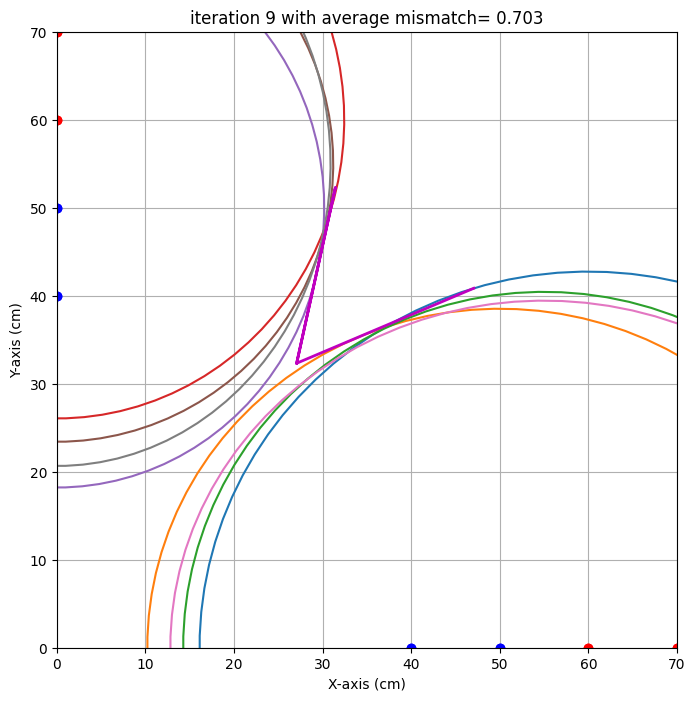

end iteration 9 with average mismatch= 0.703
end iteration 10 with average mismatch= 0.699
end iteration 11 with average mismatch= 0.670
end iteration 12 with average mismatch= 0.667
end iteration 13 with average mismatch= 0.664
end iteration 14 with average mismatch= 0.662
end iteration 15 with average mismatch= 0.660
end iteration 16 with average mismatch= 0.660
end iteration 17 with average mismatch= 0.659
end iteration 18 with average mismatch= 0.659
end iteration 19 with average mismatch= 0.659
end iteration 20 with average mismatch= 0.643
end iteration 21 with average mismatch= 0.640
end iteration 22 with average mismatch= 0.638
end iteration 23 with average mismatch= 0.638
end iteration 24 with average mismatch= 0.638
end iteration 25 with average mismatch= 0.638
end iteration 26 with average mismatch= 0.638
end iteration 27 with average mismatch= 0.638
end iteration 28 with average mismatch= 0.638
end iteration 29 with average mismatch= 0.638
Last iteration, also determine unce

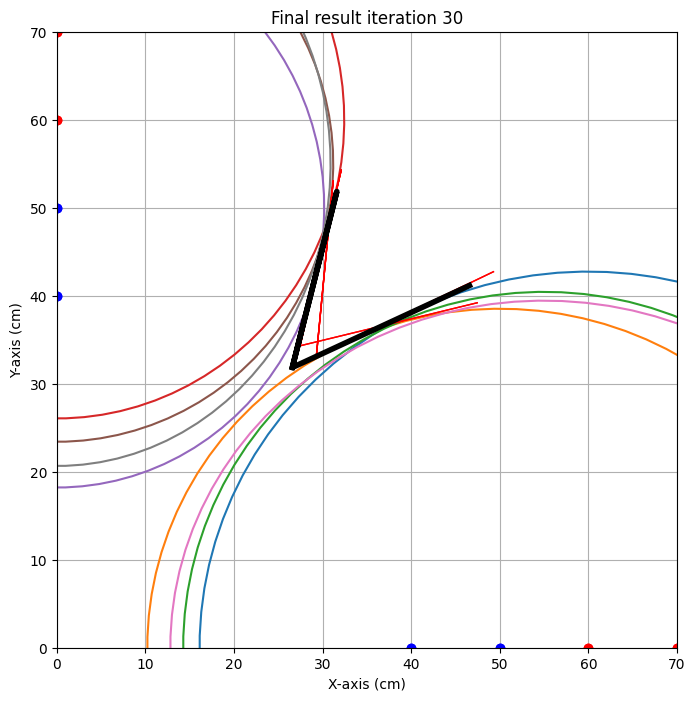

{'alpha': np.float64(24.979062936932834), 'alpha_eps': np.float64(11.239988217942471), 'beta': np.float64(14.10580277707593), 'beta_eps': np.float64(8.650398481003231), 'x0': np.float64(26.57813998634748), 'x0_eps': np.float64(2.7071065520019886), 'y0': np.float64(31.843284577158148), 'y0_eps': np.float64(2.4657263772273446)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  70   0  50   0  72.2
1  60   0  40   0  70.6
2  60   0  50   0  69.0
3   0  70   0  50  94.5
4   0  60   0  40  93.5
5   0  60   0  50  90.4
6  70   0  40   0  75.4
7   0  70   0  40  93.4


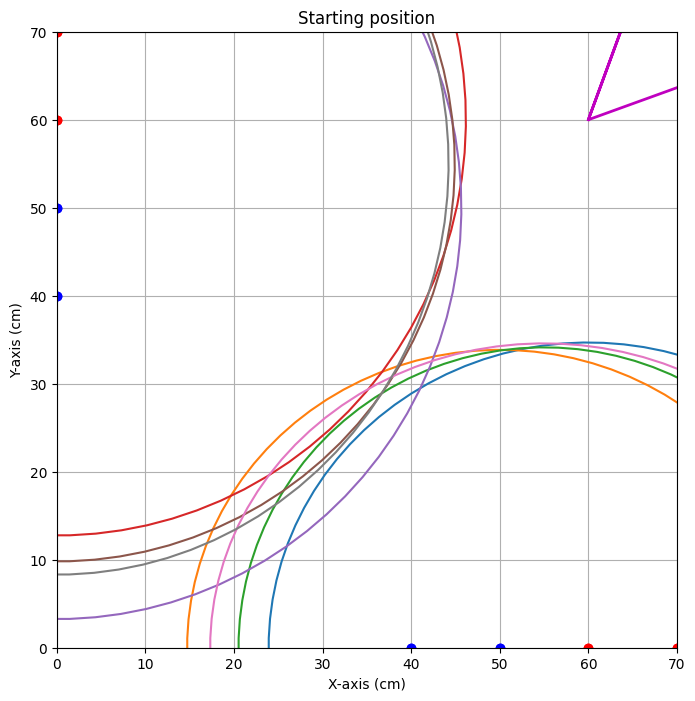


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=45.741


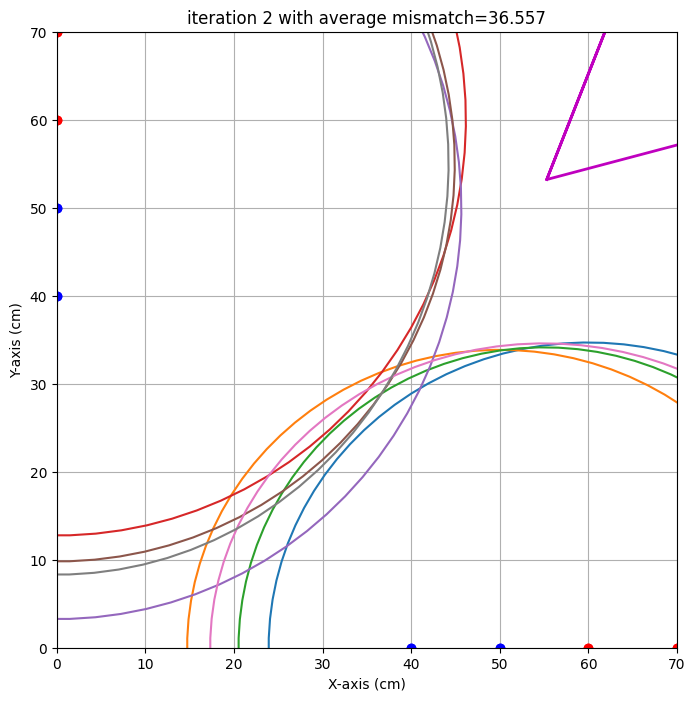

end iteration 2 with average mismatch=36.557


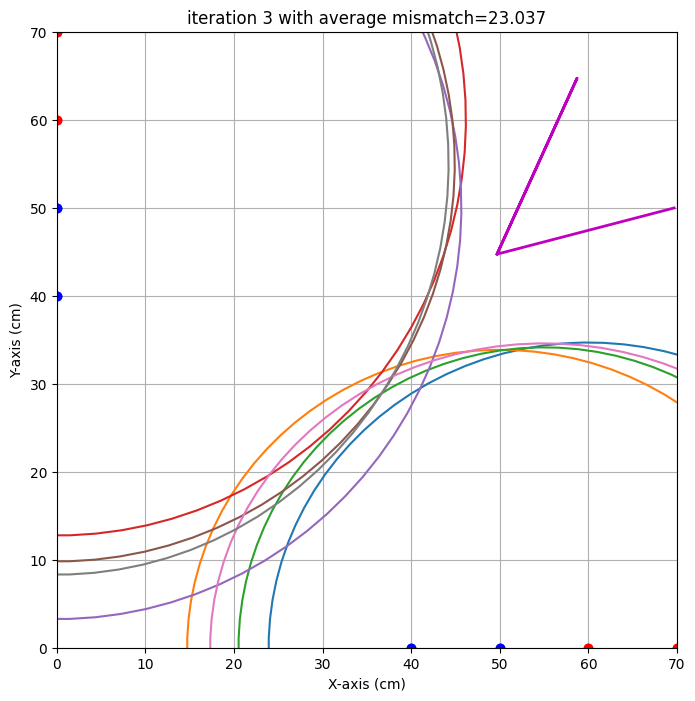

end iteration 3 with average mismatch=23.037


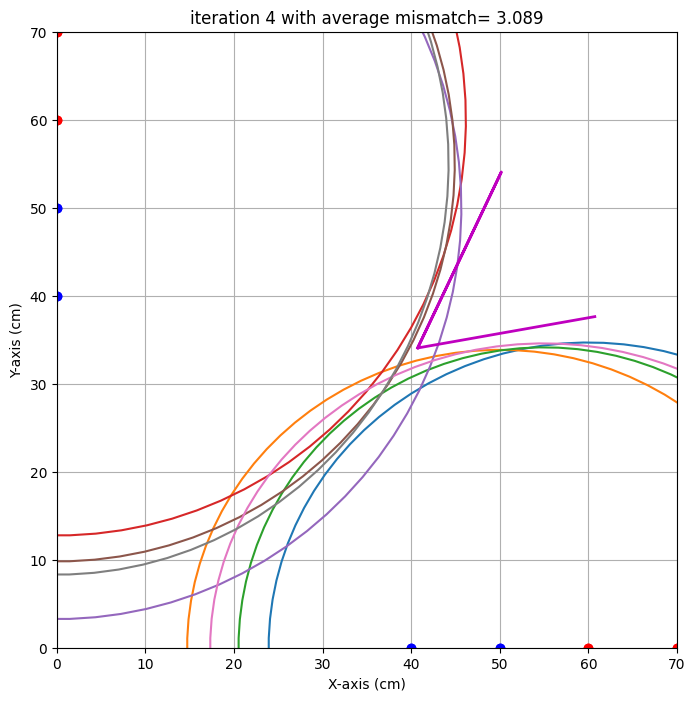

end iteration 4 with average mismatch= 3.089


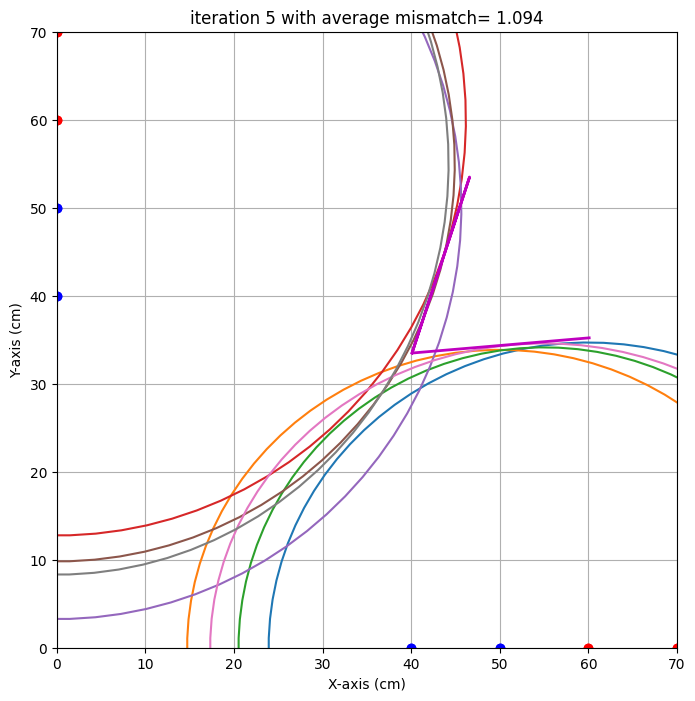

end iteration 5 with average mismatch= 1.094
end iteration 6 with average mismatch= 1.020
end iteration 7 with average mismatch= 1.004
end iteration 8 with average mismatch= 1.003
end iteration 9 with average mismatch= 0.982


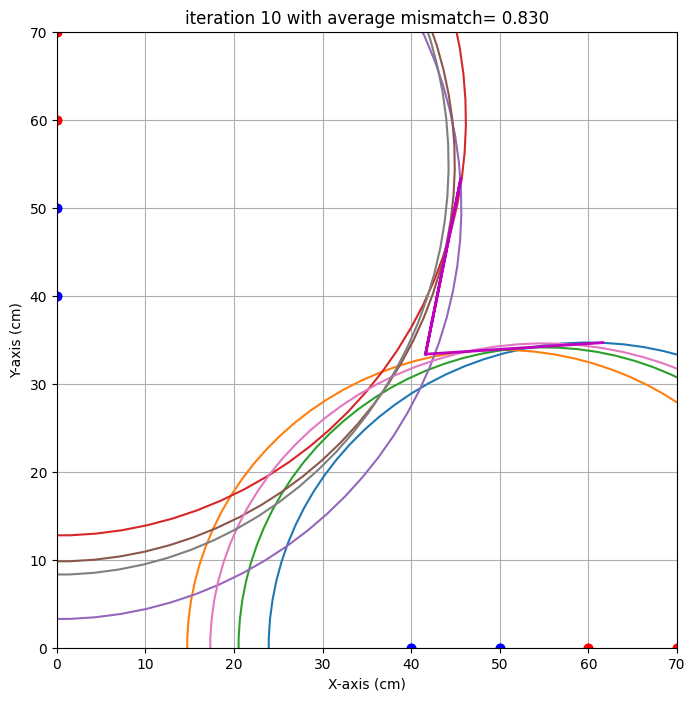

end iteration 10 with average mismatch= 0.830


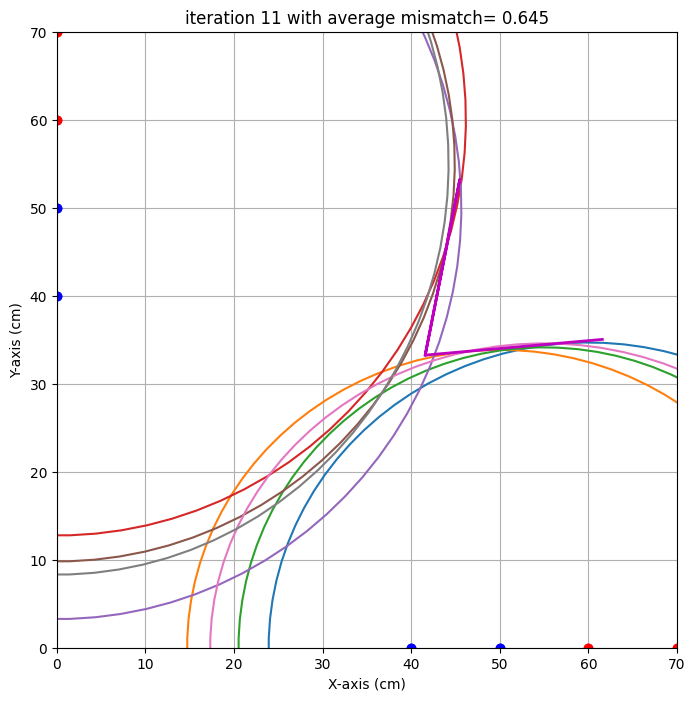

end iteration 11 with average mismatch= 0.645
end iteration 12 with average mismatch= 0.645
end iteration 13 with average mismatch= 0.645
end iteration 14 with average mismatch= 0.645
end iteration 15 with average mismatch= 0.645
end iteration 16 with average mismatch= 0.645
end iteration 17 with average mismatch= 0.645
end iteration 18 with average mismatch= 0.645
end iteration 19 with average mismatch= 0.645
end iteration 20 with average mismatch= 0.645
end iteration 21 with average mismatch= 0.645
end iteration 22 with average mismatch= 0.645
end iteration 23 with average mismatch= 0.645
end iteration 24 with average mismatch= 0.645
end iteration 25 with average mismatch= 0.645
end iteration 26 with average mismatch= 0.645
end iteration 27 with average mismatch= 0.645
end iteration 28 with average mismatch= 0.645
end iteration 29 with average mismatch= 0.645
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 

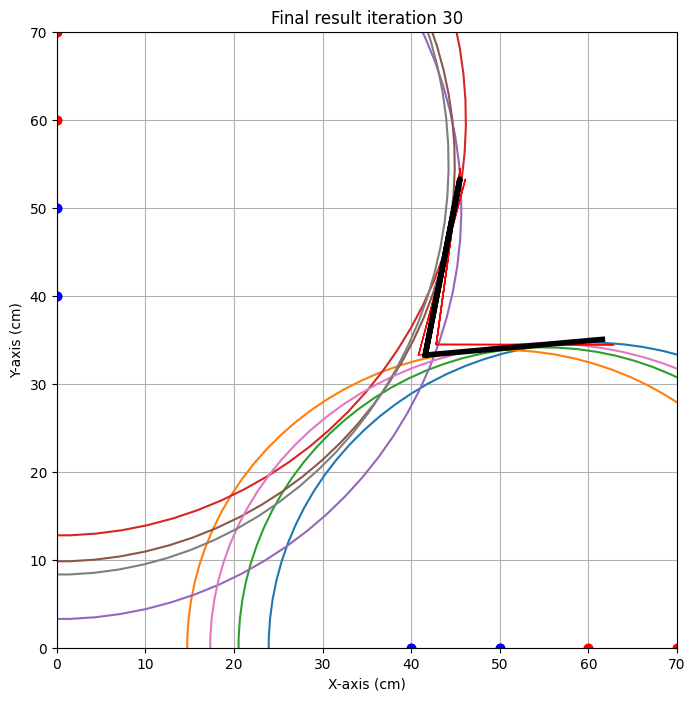

{'alpha': np.float64(5.09835457432105), 'alpha_eps': np.float64(5.180256560529426), 'beta': np.float64(11.076870819188803), 'beta_eps': np.float64(3.750895950989813), 'x0': np.float64(41.58067708751708), 'x0_eps': np.float64(1.2481480703494086), 'y0': np.float64(33.252018247299205), 'y0_eps': np.float64(1.2075670253794186)}
locatie 1 
x0 target is : 24.0. Gevonden waarde: 26.6 cm met een standaardafwijking van 2.7 cm 
y0 target is : 31.0. Gevonden waarde: 31.8 cm met een standaardafwijking van 2.5 cm 
alpha target is : 25.0. Gevonden waarde: 25.0 graden met een standaardafwijking van 11.2 graad 
beta target is : 10.0. Gevonden waarde: 14.1 graden met een standaardafwijking van 8.7 graad 

locatie 2 
x0 target is : 37.0. Gevonden waarde: 41.6 cm met een standaardafwijking van 1.2 cm 
y0 target is : 32.9. Gevonden waarde: 33.3 cm met een standaardafwijking van 1.2 cm 
alpha target is : 4.0. Gevonden waarde: 5.1 graden met een standaardafwijking van 5.2 graad 
beta target is : 23.0. Gevon

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 24,
                    'y0': 31,
                    'alpha' : 25,
                    'beta' : 10},
           'locatie 2':{'x0': 37 ,
                    'y0': 32.9,
                    'alpha' : 4 ,
                    'beta' : 23 }
            }
           
# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [70,0,50,0,87.8],
    [60,0,40,0,79.6],
    [60,0,50,0,81.5],
    [0,70,0,50,67.9],  
    [0,60,0,40,63.6],
    [0,60,0,50,63.2],
    [70,0,40,0,84.4],
    [0,70,0,40,68.7],
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [70,0,50,0,72.2],
    [60,0,40,0,70.6],
    [60,0,50,0,69.0],
    [0,70,0,50,94.5],  
    [0,60,0,40,93.5],
    [0,60,0,50,90.4],
    [70,0,40,0,75.4],
    [0,70,0,40,93.4],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

Iteratie 2:

locatie 1
Running the imaging algorithm with the following data:
    xs  ys  xr  yr     R
0   70   0  50   0  88.6
1   70   0  70   0  93.6
2   60   0  50   0  86.5
3   65   0  55   0  88.6
4   70   0  55   0  93.3
5   65   0  50   0  88.3
6    0  70   0  50  75.5
7    0  60   0  40  69.5
8    0  60   0  50  66.8
9    0  70   0  40  74.0
10   0  65   0  45  66.1
11   0  70   0  45  69.8


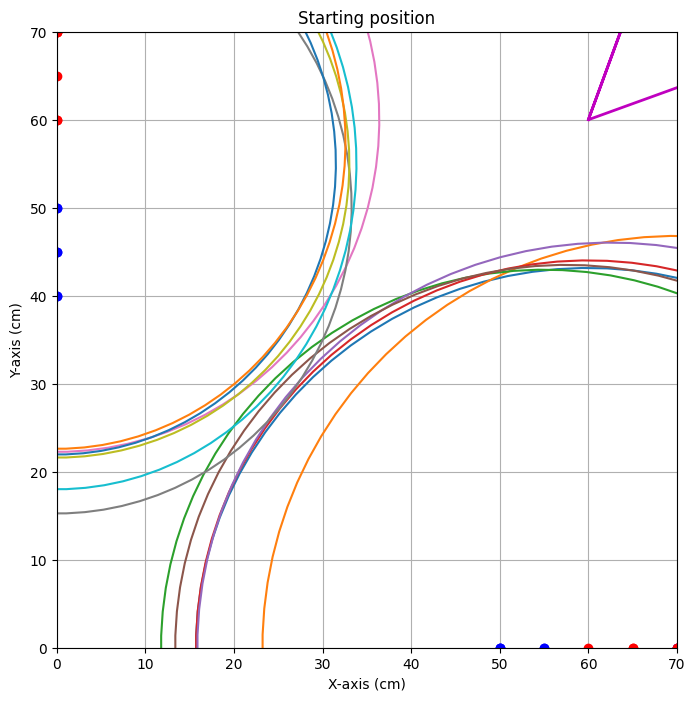


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=47.308


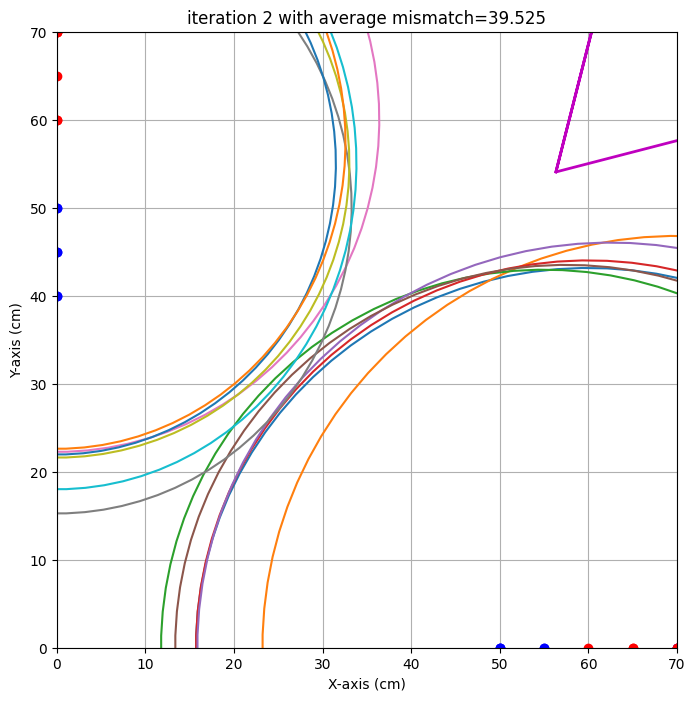

end iteration 2 with average mismatch=39.525


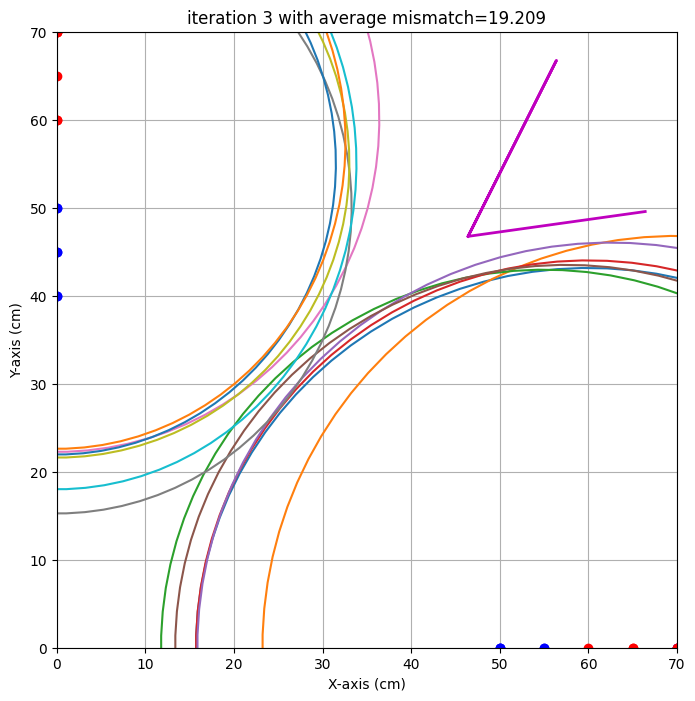

end iteration 3 with average mismatch=19.209


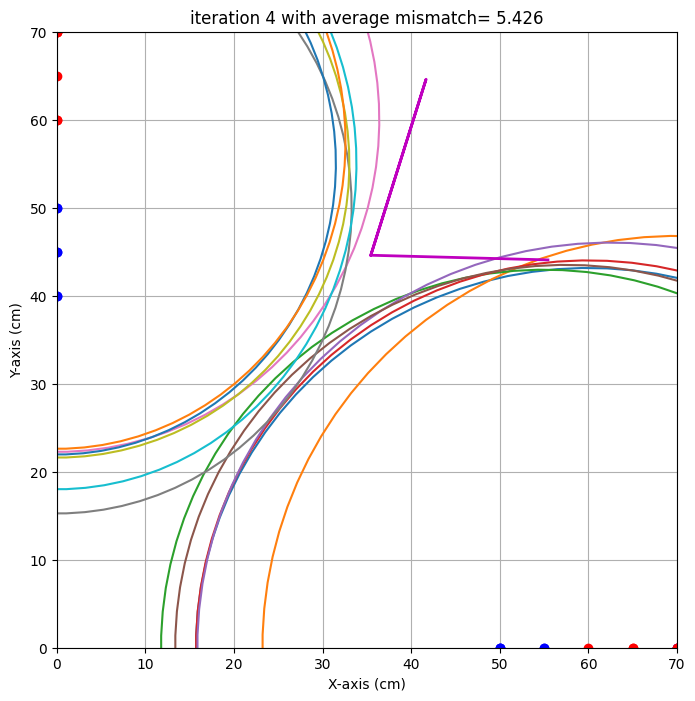

end iteration 4 with average mismatch= 5.426


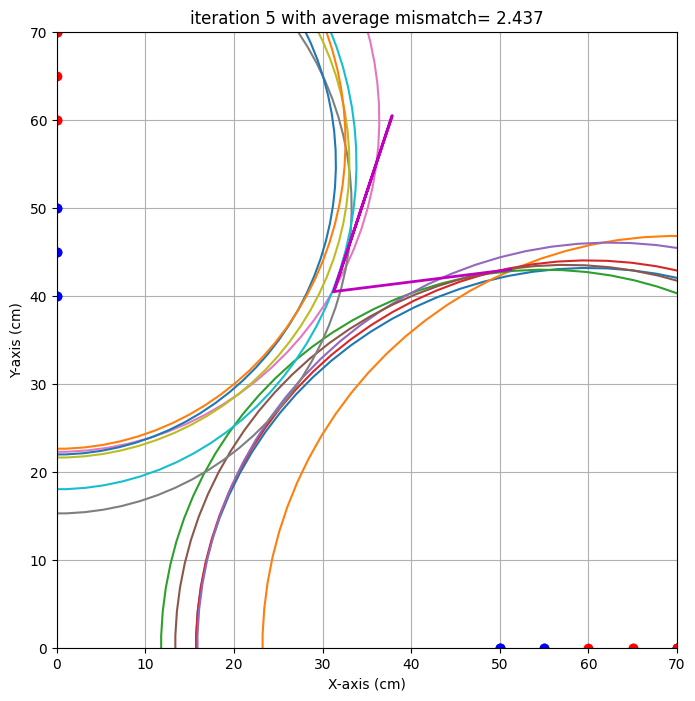

end iteration 5 with average mismatch= 2.437
end iteration 6 with average mismatch= 2.394
end iteration 7 with average mismatch= 2.252
end iteration 8 with average mismatch= 2.113
end iteration 9 with average mismatch= 2.045
end iteration 10 with average mismatch= 2.045
end iteration 11 with average mismatch= 2.045
end iteration 12 with average mismatch= 1.981
end iteration 13 with average mismatch= 1.964
end iteration 14 with average mismatch= 1.945
end iteration 15 with average mismatch= 1.942
end iteration 16 with average mismatch= 1.941
end iteration 17 with average mismatch= 1.941
end iteration 18 with average mismatch= 1.941
end iteration 19 with average mismatch= 1.941
end iteration 20 with average mismatch= 1.941
end iteration 21 with average mismatch= 1.941
end iteration 22 with average mismatch= 1.941
end iteration 23 with average mismatch= 1.941
end iteration 24 with average mismatch= 1.932
end iteration 25 with average mismatch= 1.932
end iteration 26 with average mismatch=

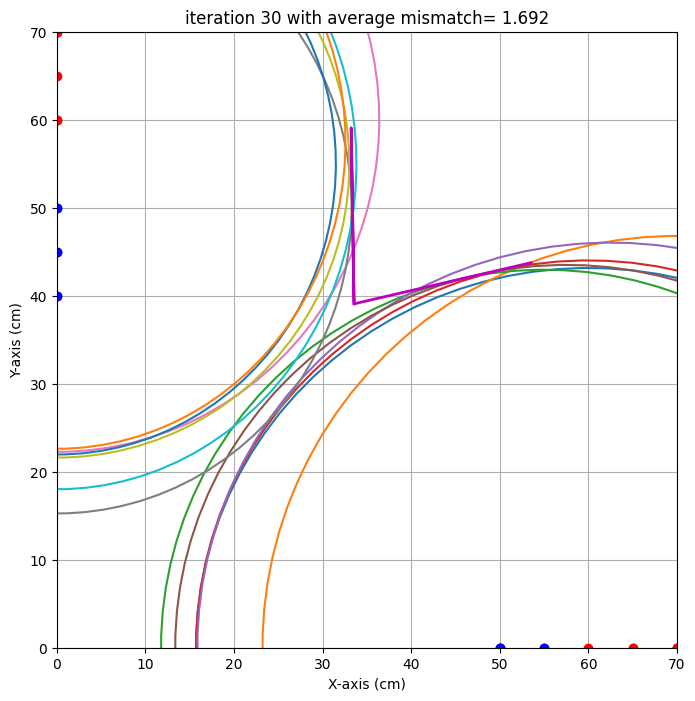

end iteration 30 with average mismatch= 1.692
###############################################################################
end of iteration  30
Best alpha=  13.17 with uncertainty=  10.49
Best beta =  -0.92 with uncertainty=  11.22
Best x0   =  33.55 with uncertainty=   3.00
Best y0   =  39.08 with uncertainty=   3.36
###############################################################################


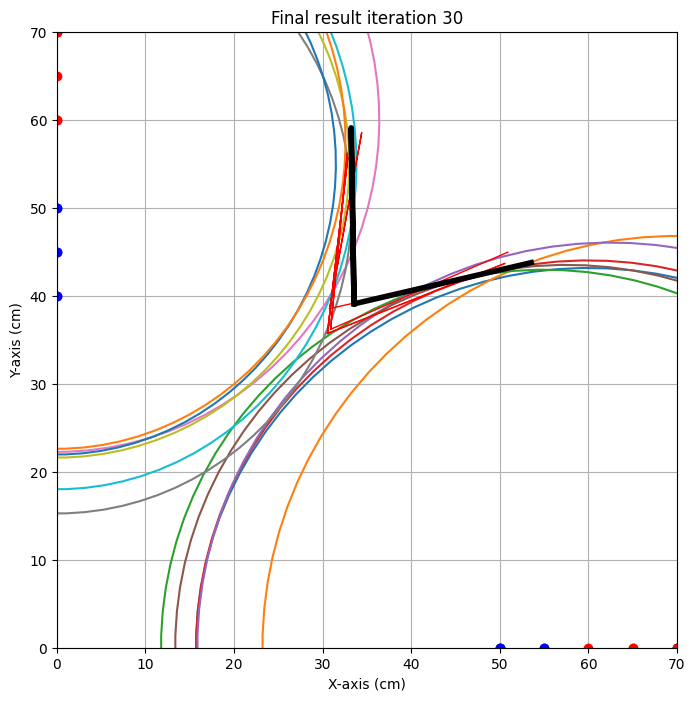

{'alpha': np.float64(13.165231308391355), 'alpha_eps': np.float64(10.493610235670928), 'beta': np.float64(-0.9196453089006011), 'beta_eps': np.float64(11.215385887049038), 'x0': np.float64(33.54741949222674), 'x0_eps': np.float64(2.999545011040386), 'y0': np.float64(39.07788570618347), 'y0_eps': np.float64(3.3648755975547573)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  70   0  50   0  72.2
1  60   0  40   0  70.6
2  60   0  50   0  69.0
3   0  70   0  50  94.5
4   0  60   0  40  93.5
5   0  60   0  50  90.4
6  70   0  40   0  75.4
7   0  70   0  40  93.4


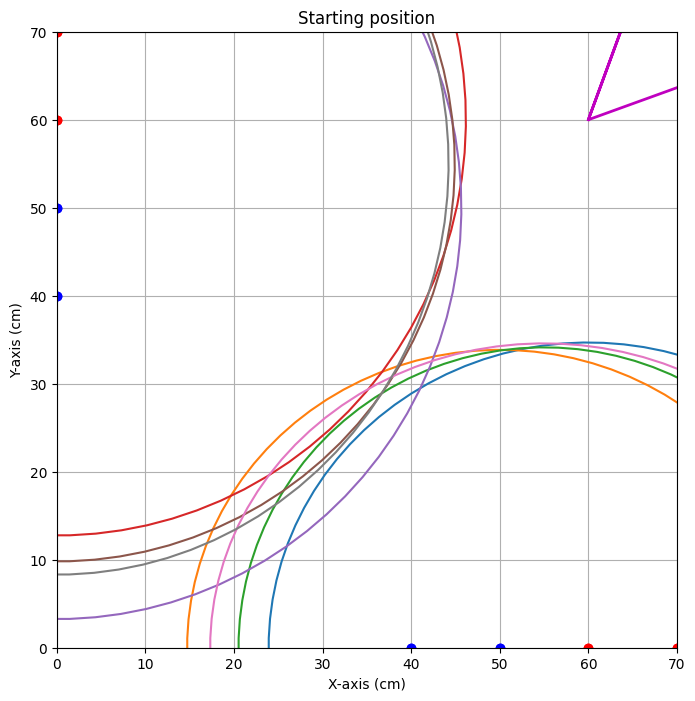


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=45.741


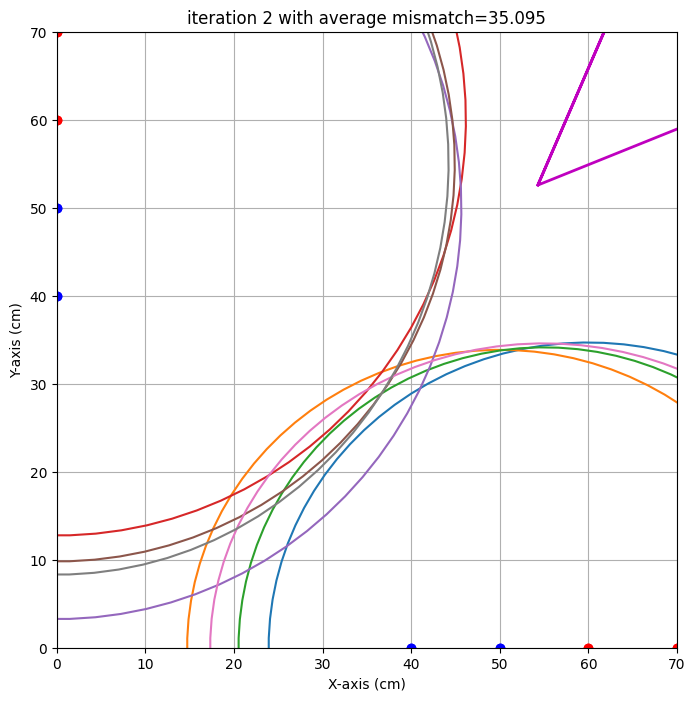

end iteration 2 with average mismatch=35.095


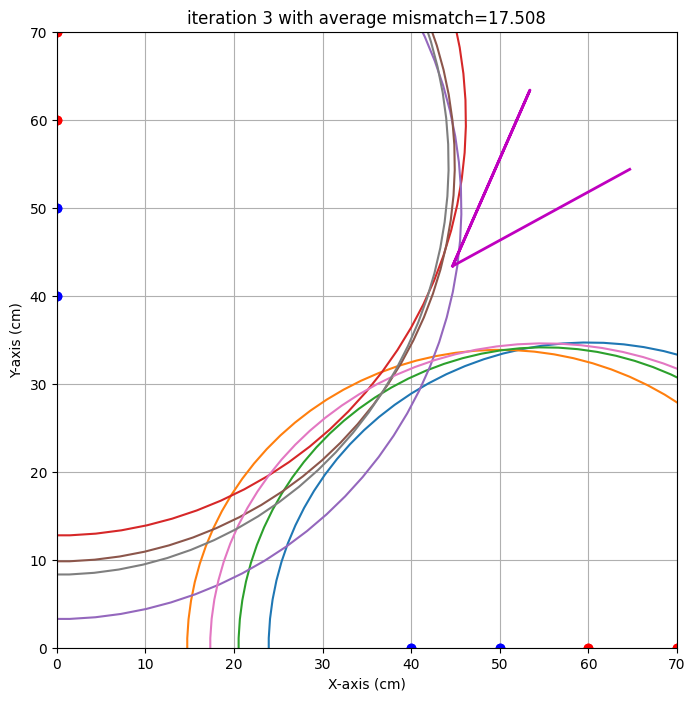

end iteration 3 with average mismatch=17.508


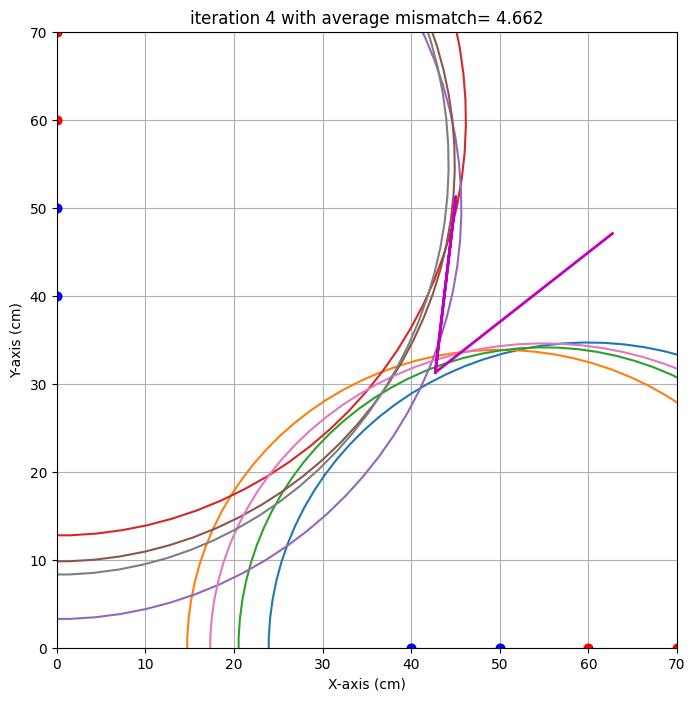

end iteration 4 with average mismatch= 4.662
end iteration 5 with average mismatch= 4.515


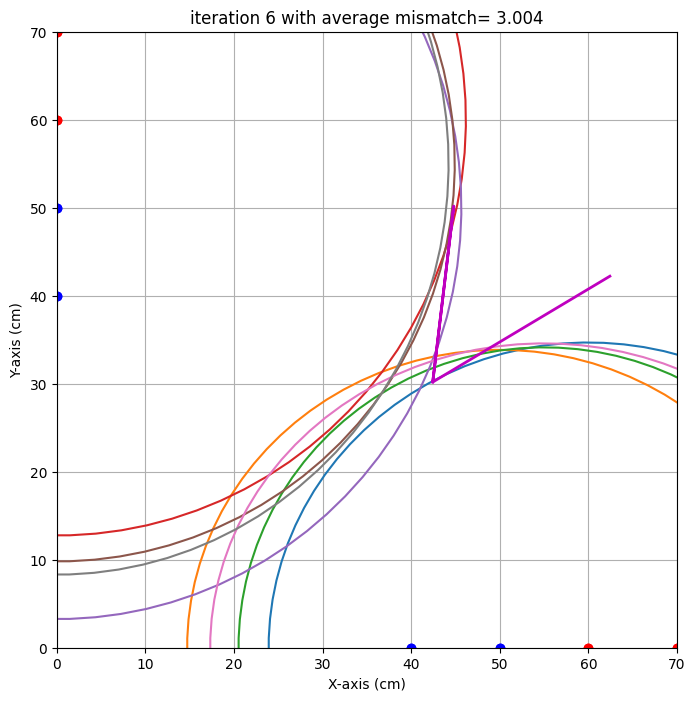

end iteration 6 with average mismatch= 3.004
end iteration 7 with average mismatch= 3.004
end iteration 8 with average mismatch= 3.004
end iteration 9 with average mismatch= 3.004


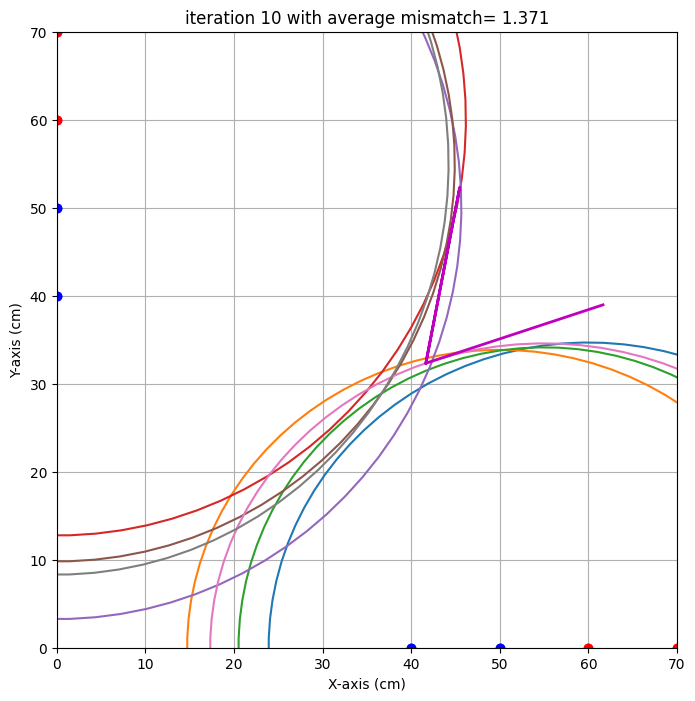

end iteration 10 with average mismatch= 1.371


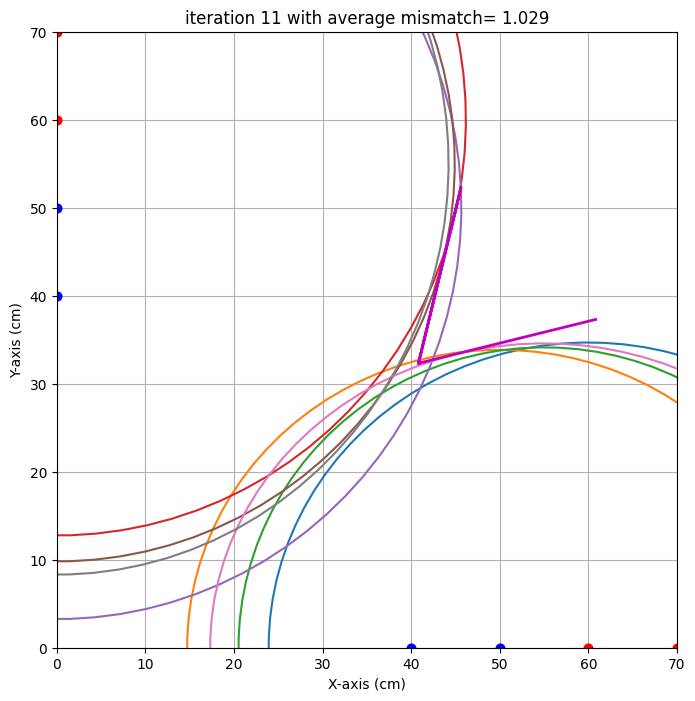

end iteration 11 with average mismatch= 1.029


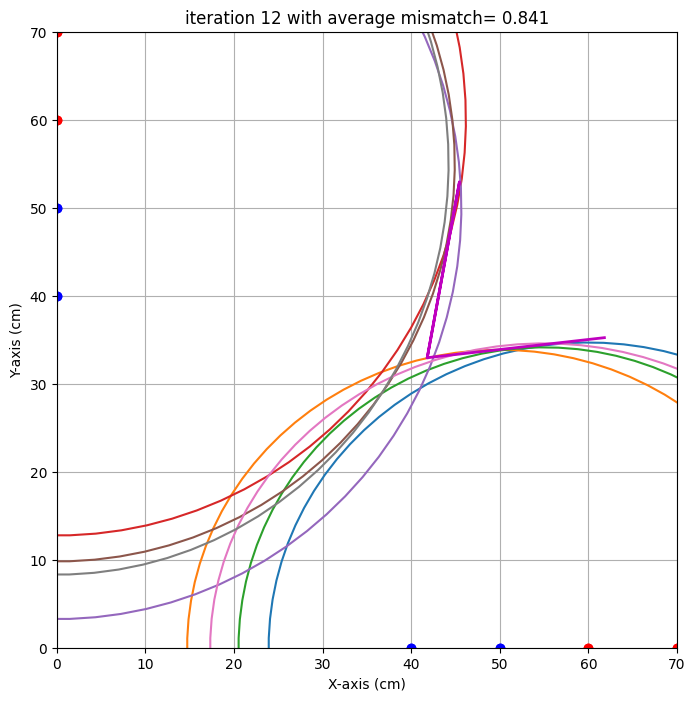

end iteration 12 with average mismatch= 0.841
end iteration 13 with average mismatch= 0.787
end iteration 14 with average mismatch= 0.761
end iteration 15 with average mismatch= 0.710
end iteration 16 with average mismatch= 0.701
end iteration 17 with average mismatch= 0.670
end iteration 18 with average mismatch= 0.658
end iteration 19 with average mismatch= 0.656
end iteration 20 with average mismatch= 0.656
end iteration 21 with average mismatch= 0.656
end iteration 22 with average mismatch= 0.656
end iteration 23 with average mismatch= 0.656
end iteration 24 with average mismatch= 0.656
end iteration 25 with average mismatch= 0.656
end iteration 26 with average mismatch= 0.656
end iteration 27 with average mismatch= 0.656
end iteration 28 with average mismatch= 0.656
end iteration 29 with average mismatch= 0.656
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.656
#################

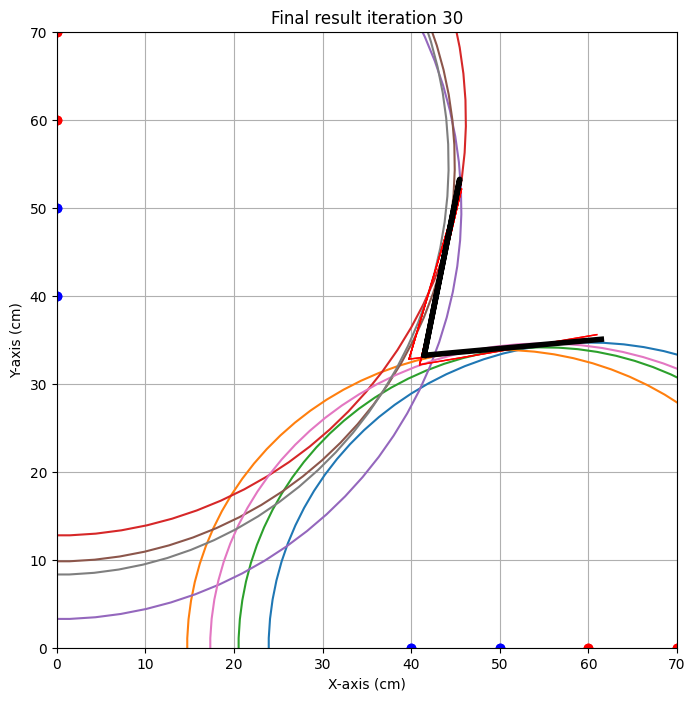

{'alpha': np.float64(5.204941227225545), 'alpha_eps': np.float64(4.497375393201544), 'beta': np.float64(11.341147516535532), 'beta_eps': np.float64(5.068935056090432), 'x0': np.float64(41.466272912535466), 'x0_eps': np.float64(1.7087738227453997), 'y0': np.float64(33.22636721372646), 'y0_eps': np.float64(1.0682909131529144)}
locatie 1 
x0 target is : 31.0. Gevonden waarde: 33.5 cm met een standaardafwijking van 3.0 cm 
y0 target is : 32.7. Gevonden waarde: 39.1 cm met een standaardafwijking van 3.4 cm 
alpha target is : 38.0. Gevonden waarde: 13.2 graden met een standaardafwijking van 10.5 graad 
beta target is : 7.0. Gevonden waarde: -0.9 graden met een standaardafwijking van 11.2 graad 

locatie 2 
x0 target is : 37.0. Gevonden waarde: 41.5 cm met een standaardafwijking van 1.7 cm 
y0 target is : 32.9. Gevonden waarde: 33.2 cm met een standaardafwijking van 1.1 cm 
alpha target is : 4.0. Gevonden waarde: 5.2 graden met een standaardafwijking van 4.5 graad 
beta target is : 23.0. Gevo

In [12]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 31,
                    'y0': 32.7,
                    'alpha' : 38,
                    'beta' : 7},
           'locatie 2':{'x0': 37 ,
                    'y0': 32.9,
                    'alpha' : 4 ,
                    'beta' : 23 }
            }
           
# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [70,0,50,0,88.6],
    #[60,0,40,0,200],
    [70,0,70,0,93.6],
    [60,0,50,0,86.5],
    [65,0,55,0,88.6],
    [70,0,55,0,93.3],  
    [65,0,50,0,88.3],
    [0,70,0,50,75.5],
    [0,60,0,40,69.5],
    [0,60,0,50,66.8],
    [0,70,0,40,74.0],
    [0,65,0,45,66.1],
    #[0,70,0,60,200],
    #[0,70,0,55,200],
    [0,70,0,45,69.8],

   
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [70,0,50,0,72.2],
    [60,0,40,0,70.6],
    [60,0,50,0,69.0],
    [0,70,0,50,94.5],  
    [0,60,0,40,93.5],
    [0,60,0,50,90.4],
    [70,0,40,0,75.4],
    [0,70,0,40,93.4],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
    xs  ys  xr  yr     R
0   70   0  50   0  92.2
1   60   0  40   0  93.5
2   60   0  50   0  89.2
3   70   0  40   0  93.5
4   65   0  45   0  91.0
5   70   0  45   0  93.5
6    0  20   0  40  95.3
7    0  30   0  50  89.5
8    0  30   0  40  89.0
9    0  20   0  50  93.2
10   0  25   0  45  90.9


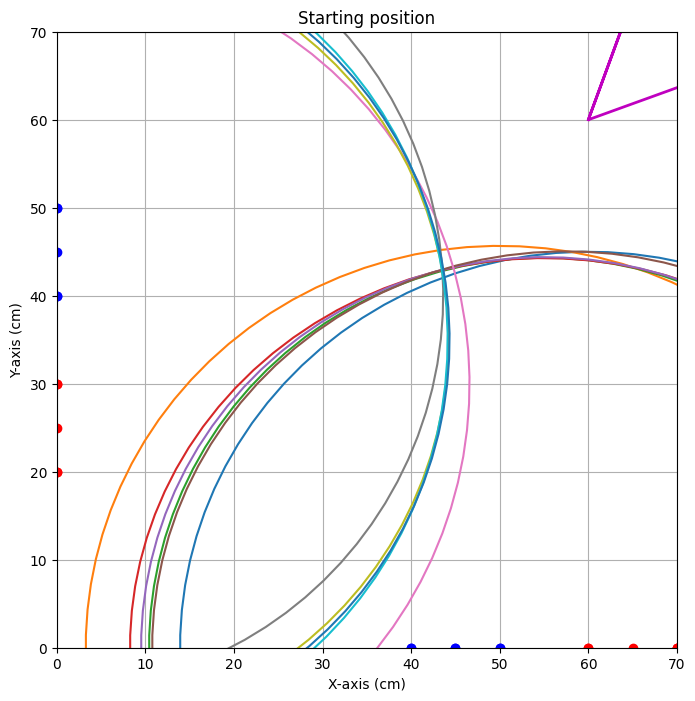


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=41.757


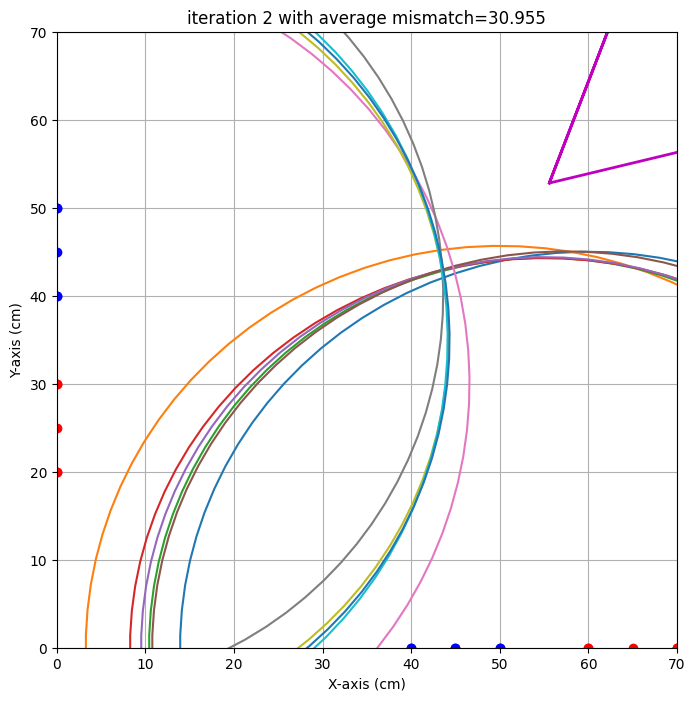

end iteration 2 with average mismatch=30.955


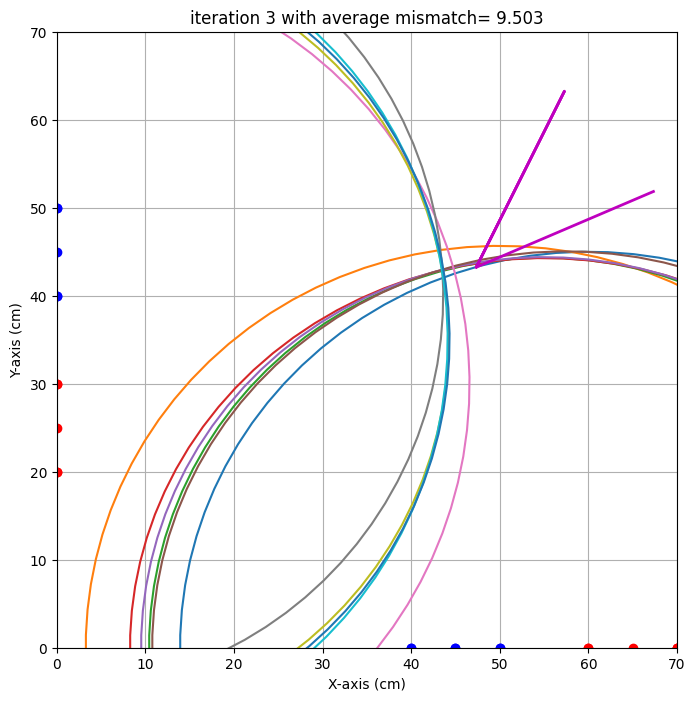

end iteration 3 with average mismatch= 9.503


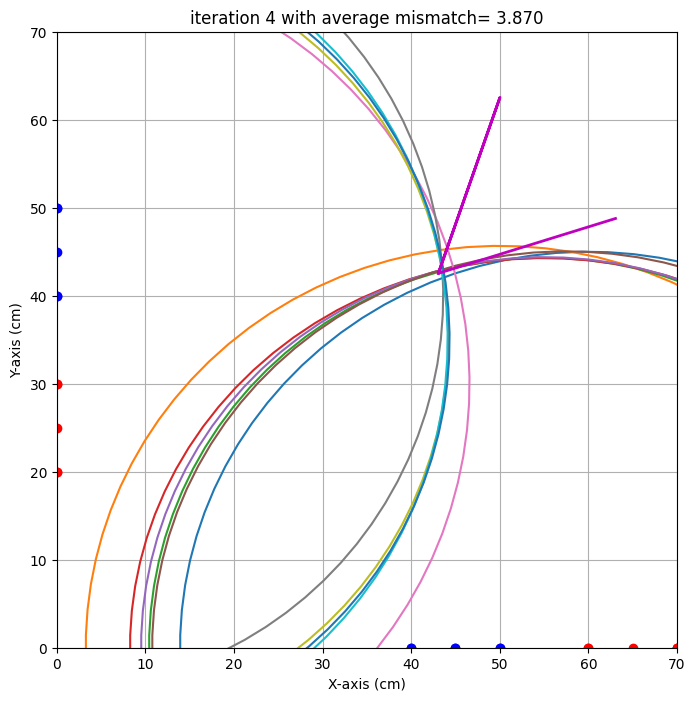

end iteration 4 with average mismatch= 3.870
end iteration 5 with average mismatch= 3.706
end iteration 6 with average mismatch= 3.512


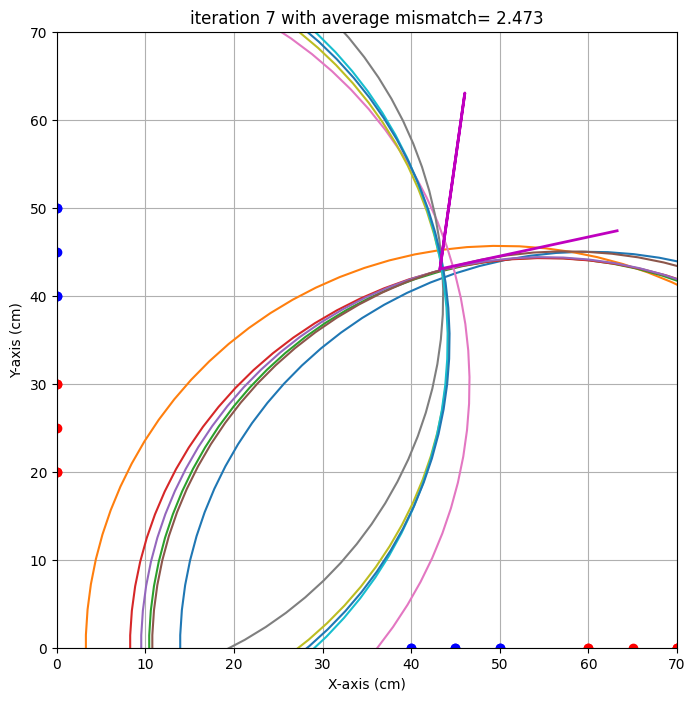

end iteration 7 with average mismatch= 2.473


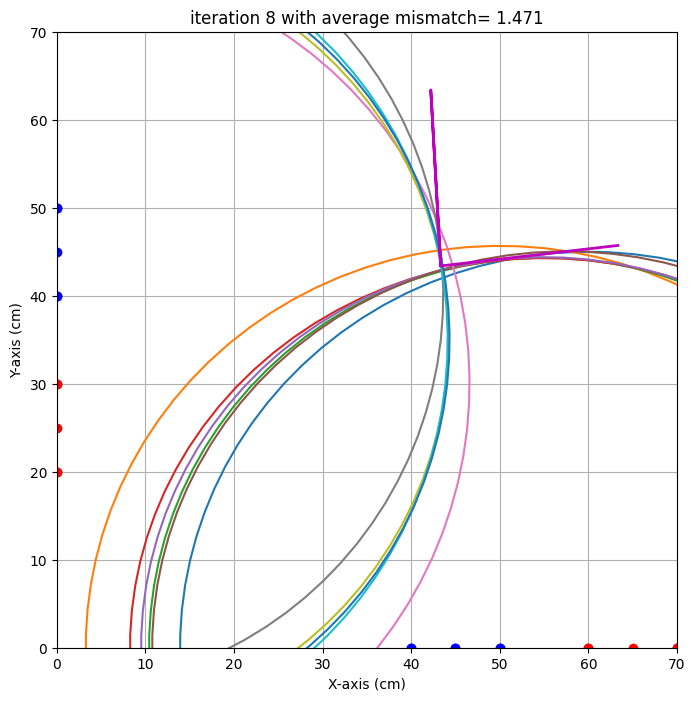

end iteration 8 with average mismatch= 1.471


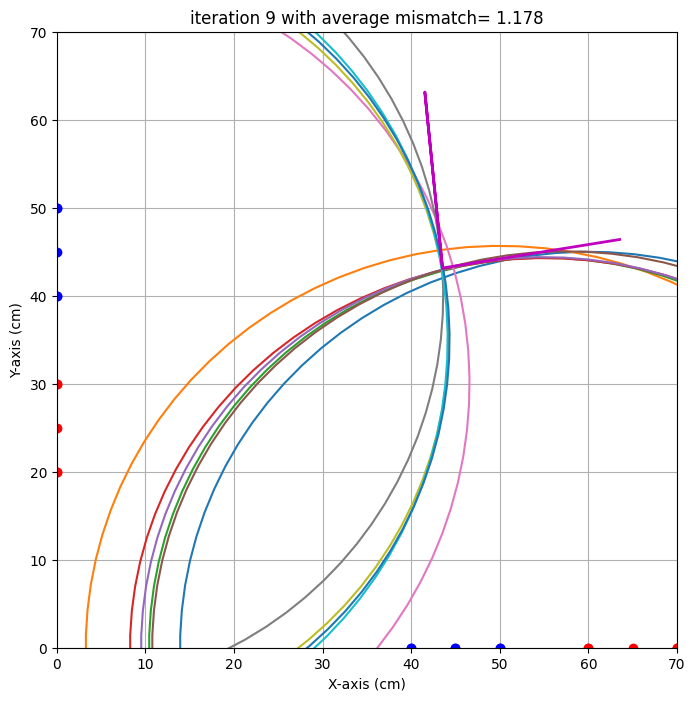

end iteration 9 with average mismatch= 1.178
end iteration 10 with average mismatch= 1.082
end iteration 11 with average mismatch= 1.074
end iteration 12 with average mismatch= 0.994
end iteration 13 with average mismatch= 0.983
end iteration 14 with average mismatch= 0.983
end iteration 15 with average mismatch= 0.983
end iteration 16 with average mismatch= 0.983
end iteration 17 with average mismatch= 0.980
end iteration 18 with average mismatch= 0.978
end iteration 19 with average mismatch= 0.978
end iteration 20 with average mismatch= 0.978
end iteration 21 with average mismatch= 0.978
end iteration 22 with average mismatch= 0.978
end iteration 23 with average mismatch= 0.978
end iteration 24 with average mismatch= 0.978
end iteration 25 with average mismatch= 0.978
end iteration 26 with average mismatch= 0.978
end iteration 27 with average mismatch= 0.978
end iteration 28 with average mismatch= 0.978
end iteration 29 with average mismatch= 0.978
Last iteration, also determine unce

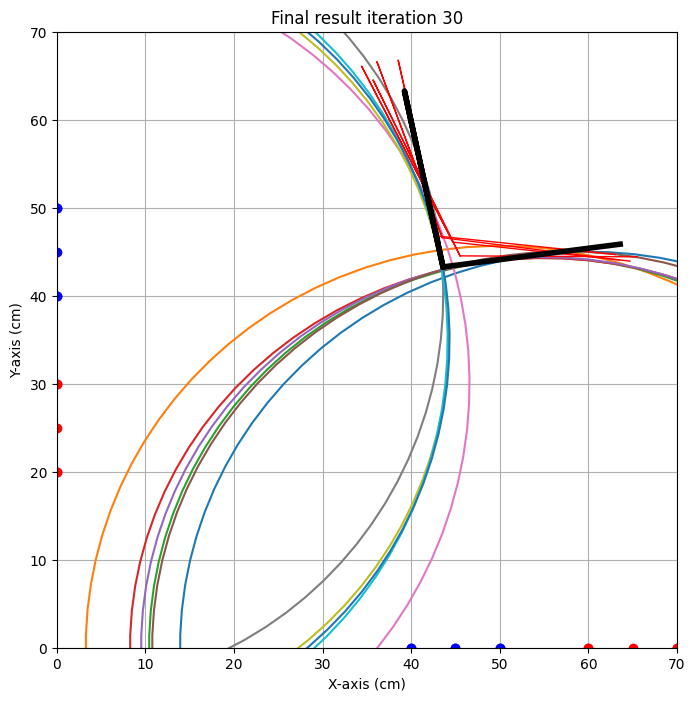

{'alpha': np.float64(7.360942240172836), 'alpha_eps': np.float64(14.584134247152623), 'beta': np.float64(-12.284482960046144), 'beta_eps': np.float64(14.989653998713603), 'x0': np.float64(43.591229081504736), 'x0_eps': np.float64(1.9220803789042549), 'y0': np.float64(43.27338968320043), 'y0_eps': np.float64(3.5012683023226856)}
test locatie 
x0 target is : 43.0. Gevonden waarde: 43.6 cm met een standaardafwijking van 1.9 cm 
y0 target is : 43.9. Gevonden waarde: 43.3 cm met een standaardafwijking van 3.5 cm 
alpha target is : 7.0. Gevonden waarde: 7.4 graden met een standaardafwijking van 14.6 graad 
beta target is : -17.0. Gevonden waarde: -12.3 graden met een standaardafwijking van 15.0 graad 



In [13]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 43 ,
                    'y0': 43.9 ,
                    'alpha' : 7 ,
                    'beta' : -17 
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [70,0,50,0,92.2],
                    [60,0,40,0,93.5],
                    [60,0,50,0,89.2],
                    [70,0,40,0,93.5],
                    [65,0,45,0,91.0],
                    [70,0,45,0,93.5],
                    #[0,70,0,50,200],
                    [0,20,0,40,95.3],
                    [0,30,0,50,89.5],
                    [0,30,0,40,89.0],
                    [0,20,0,50,93.2],
                    [0,25,0,45,90.9],
                    #[0,35,0,25,95.5],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: 
![Alt](SchemaMatteo.jpeg "Title")

Van onze algoritmes hebben we deze gekozen omdat deze de beste resultaten geeft en simpeler is door het op te splitsen in de twee assen. We hebben geen tussentijdse foto's genomen van onze iteraties. We hebben wel de eerste versie in het blauw gemaakt en aanpassingen in het zwart. Tijdens het testen bleek dat er veel meer metingen nodig waren dus die hebben we toegevoegd.

Figuur: 
![Alt](Iteratie1.jpeg "Title")
